In [13]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import random

In [14]:
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = 'all'


# 1. Line Plot
When to use:

- To show trends over time (e.g., sales growth, profit changes).

- Best for Numerical-continuous data.

**Columns involved:** 

- 1 categorical (time/date) → X-axis.

- 1 numerical → Y-axis.



In [16]:
#loading the dataset
store_df=pd.read_excel(r"C:\Users\chidv\Downloads\Data_sets\Superstore.xlsx")
store_df

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9989,9990,CA-2014-110422,2014-01-21,2014-01-23,Second Class,TB-21400,Tom Boeckenhauer,Consumer,United States,Miami,...,33180,South,FUR-FU-10001889,Furniture,Furnishings,Ultra Door Pull Handle,25.2480,3,0.20,4.1028
9990,9991,CA-2017-121258,2017-02-26,2017-03-03,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,...,92627,West,FUR-FU-10000747,Furniture,Furnishings,Tenex B1-RE Series Chair Mats for Low Pile Car...,91.9600,2,0.00,15.6332
9991,9992,CA-2017-121258,2017-02-26,2017-03-03,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,...,92627,West,TEC-PH-10003645,Technology,Phones,Aastra 57i VoIP phone,258.5760,2,0.20,19.3932
9992,9993,CA-2017-121258,2017-02-26,2017-03-03,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,...,92627,West,OFF-PA-10004041,Office Supplies,Paper,"It's Hot Message Books with Stickers, 2 3/4"" x 5""",29.6000,4,0.00,13.3200


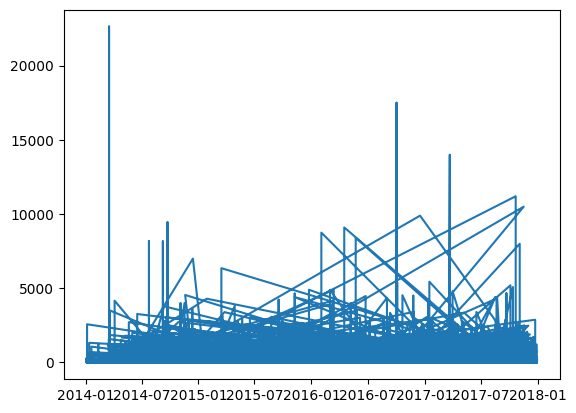

In [60]:
#our first plot'
draw=plt.plot(store_df['Order Date'],store_df.Sales)
draw

### As above seen gives a n understanding if you are ploting the raw data due to tremendious amount of data it will showcase the clumsyness in plot so we will aggregate the data to reduce the size

In [94]:
#aggregation is done by using the group


In [95]:
agg_data=store_df.groupby(['Order Date'])[['Sales']].sum() # we are aimed to find the tot data so we use the sum
agg_data

,Sales
Order Date,
2014-01-03,16.4480
2014-01-04,288.0600
2014-01-05,19.5360
2014-01-06,4407.1000
2014-01-07,87.1580
...,...
2017-12-26,814.5940
2017-12-27,177.6360
2017-12-28,1657.3508


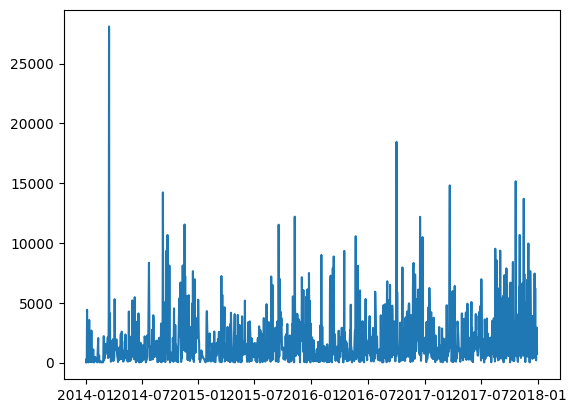

In [96]:
#now try to plot the 
plt.plot(agg_data.index,agg_data.values)

### The above map is something fine than first one but the main problem is we cannot understand by looking this so we will more aggrigate x axiz values  it to extract the perfect plot

In [97]:
store_df['Order_Date']=store_df['Order Date'].dt.to_period('Q')

In [98]:
store_df.Order_Date=store_df.Order_Date.astype(str) # we also converted the data into catogries 

In [106]:
store_df.Order_Date.unique()

array(['2016Q4', '2016Q2', '2015Q4', '2014Q2', '2017Q2', '2014Q4',
       '2014Q3', '2017Q3', '2015Q3', '2016Q1', '2017Q4', '2016Q3',
       '2015Q2', '2015Q1', '2017Q1', '2014Q1'], dtype=object)

In [80]:
# again perform the sub catogriey
agg_data=store_df.groupby(('Order_Date'))[['Sales']].sum() # we are aimed to find the tot data so we use the sum
agg_data.index

Index(['2014Q1', '2014Q2', '2014Q3', '2014Q4', '2015Q1', '2015Q2', '2015Q3',
       '2015Q4', '2016Q1', '2016Q2', '2016Q3', '2016Q4', '2017Q1', '2017Q2',
       '2017Q3', '2017Q4'],
      dtype='object', name='Order_Date')

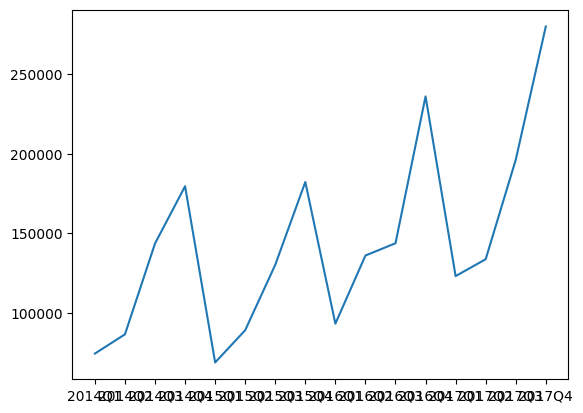

In [81]:
# now the data is small to plot it
plt.plot(agg_data.index,agg_data.values)

Figure(1500x500)


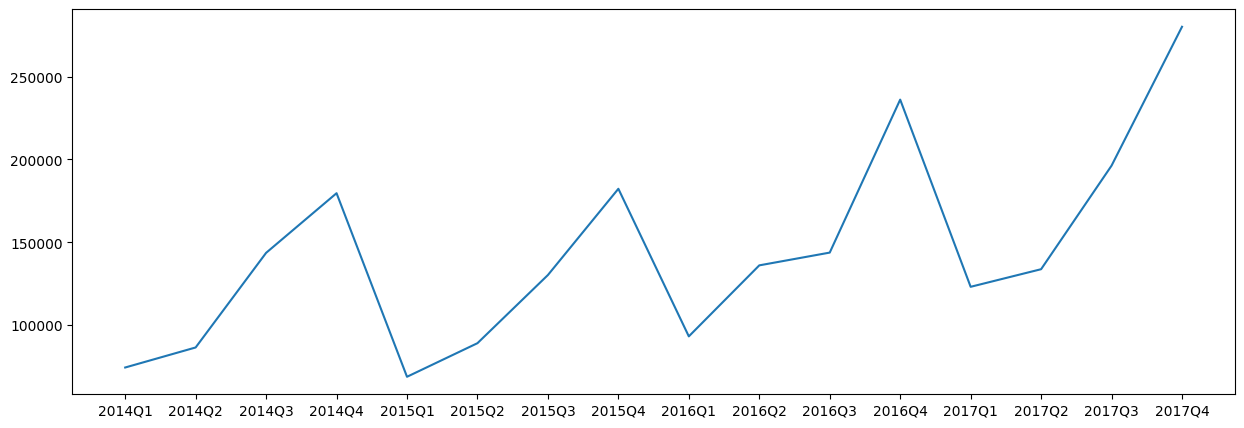

In [107]:

#resizing the plt
print(plt.figure(figsize=(15,5)))
#so we will adjust the  x asis lables by
plt.plot(agg_data.index,agg_data.values)


Figure(1500x500)


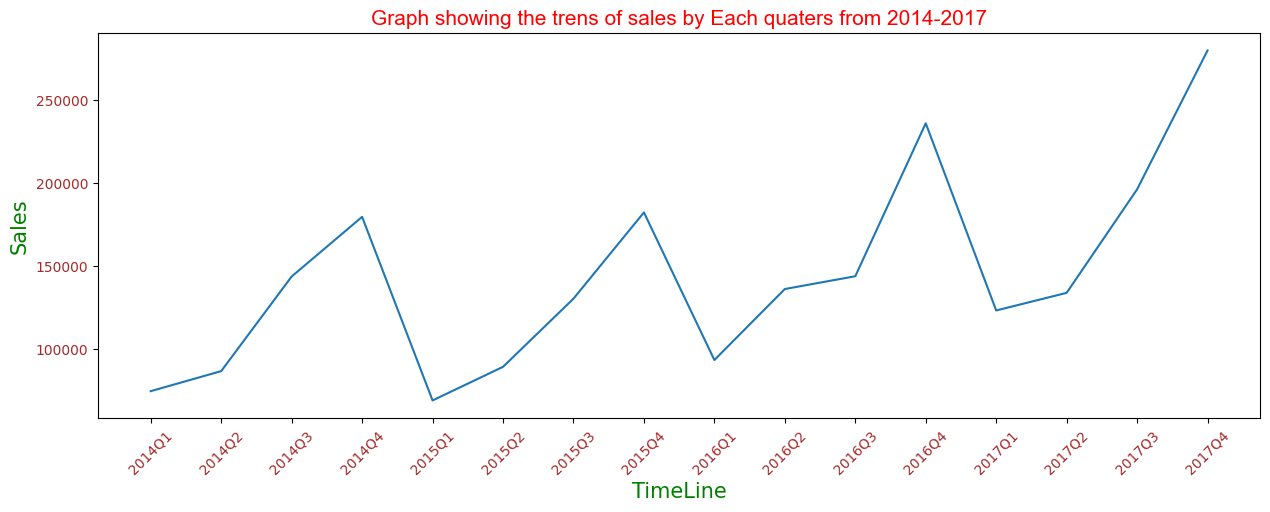

In [130]:
# Naming the graph by title x axis and y axis by labels

print(plt.figure(figsize=(15,5)))
#so we will adjust the  x asis lables by
plt.plot(agg_data.index,agg_data.values)
plt.title("Graph showing the trens of sales by Each quaters from 2014-2017",fontsize = 15, color = "red", fontname = "Arial")
plt.xlabel('TimeLine', fontsize=15,color='green')
plt.ylabel("Sales",fontsize=15,color='green')

#ticks that are points on graphs 
plt.xticks(color='Brown',rotation = 45)
plt.yticks(color='Brown');

## Multi -line ploting

In [ ]:
#from the above store data my aim is t

In [39]:
#so we are aim to show the multi line ploting over Segment catogries trend od date over segments s
#first we need to prepare the data 

array(['Consumer', 'Corporate', 'Home Office'], dtype=object)

In [115]:
aggdata=store_df.groupby(['Order_Date','Segment'])['Sales'].sum().unstack()
                                                #unstacl is used to categries behavile like this 
#'use single [] to avoid multi ins

In [116]:
aggdata

Segment,Consumer,Corporate,Home Office
Order_Date,,,
2014Q1,21964.9750,13991.9950,38490.8260
2014Q2,47851.5226,27244.6430,11442.5940
2014Q3,96103.6535,32992.5070,14537.0518
2014Q4,100176.6615,54205.7287,25245.3400
2015Q1,40962.8916,22279.7394,5609.1076
2015Q2,56330.0885,18980.0725,13814.0260
2015Q3,79398.9210,35252.0202,15608.6340
2015Q4,89844.0322,52245.4748,40207.5012
2016Q1,46671.8670,26578.4810,19986.8330


In [117]:
crssdata=pd.crosstab(store_df.Order_Date,store_df.Segment,aggfunc='sum',values=store_df.Sales)

In [118]:
aggdata.index

Index(['2014Q1', '2014Q2', '2014Q3', '2014Q4', '2015Q1', '2015Q2', '2015Q3',
       '2015Q4', '2016Q1', '2016Q2', '2016Q3', '2016Q4', '2017Q1', '2017Q2',
       '2017Q3', '2017Q4'],
      dtype='object', name='Order_Date')

In [119]:
crssdata

Segment,Consumer,Corporate,Home Office
Order_Date,,,
2014Q1,21964.9750,13991.9950,38490.8260
2014Q2,47851.5226,27244.6430,11442.5940
2014Q3,96103.6535,32992.5070,14537.0518
2014Q4,100176.6615,54205.7287,25245.3400
2015Q1,40962.8916,22279.7394,5609.1076
2015Q2,56330.0885,18980.0725,13814.0260
2015Q3,79398.9210,35252.0202,15608.6340
2015Q4,89844.0322,52245.4748,40207.5012
2016Q1,46671.8670,26578.4810,19986.8330


#original plotting happens here 


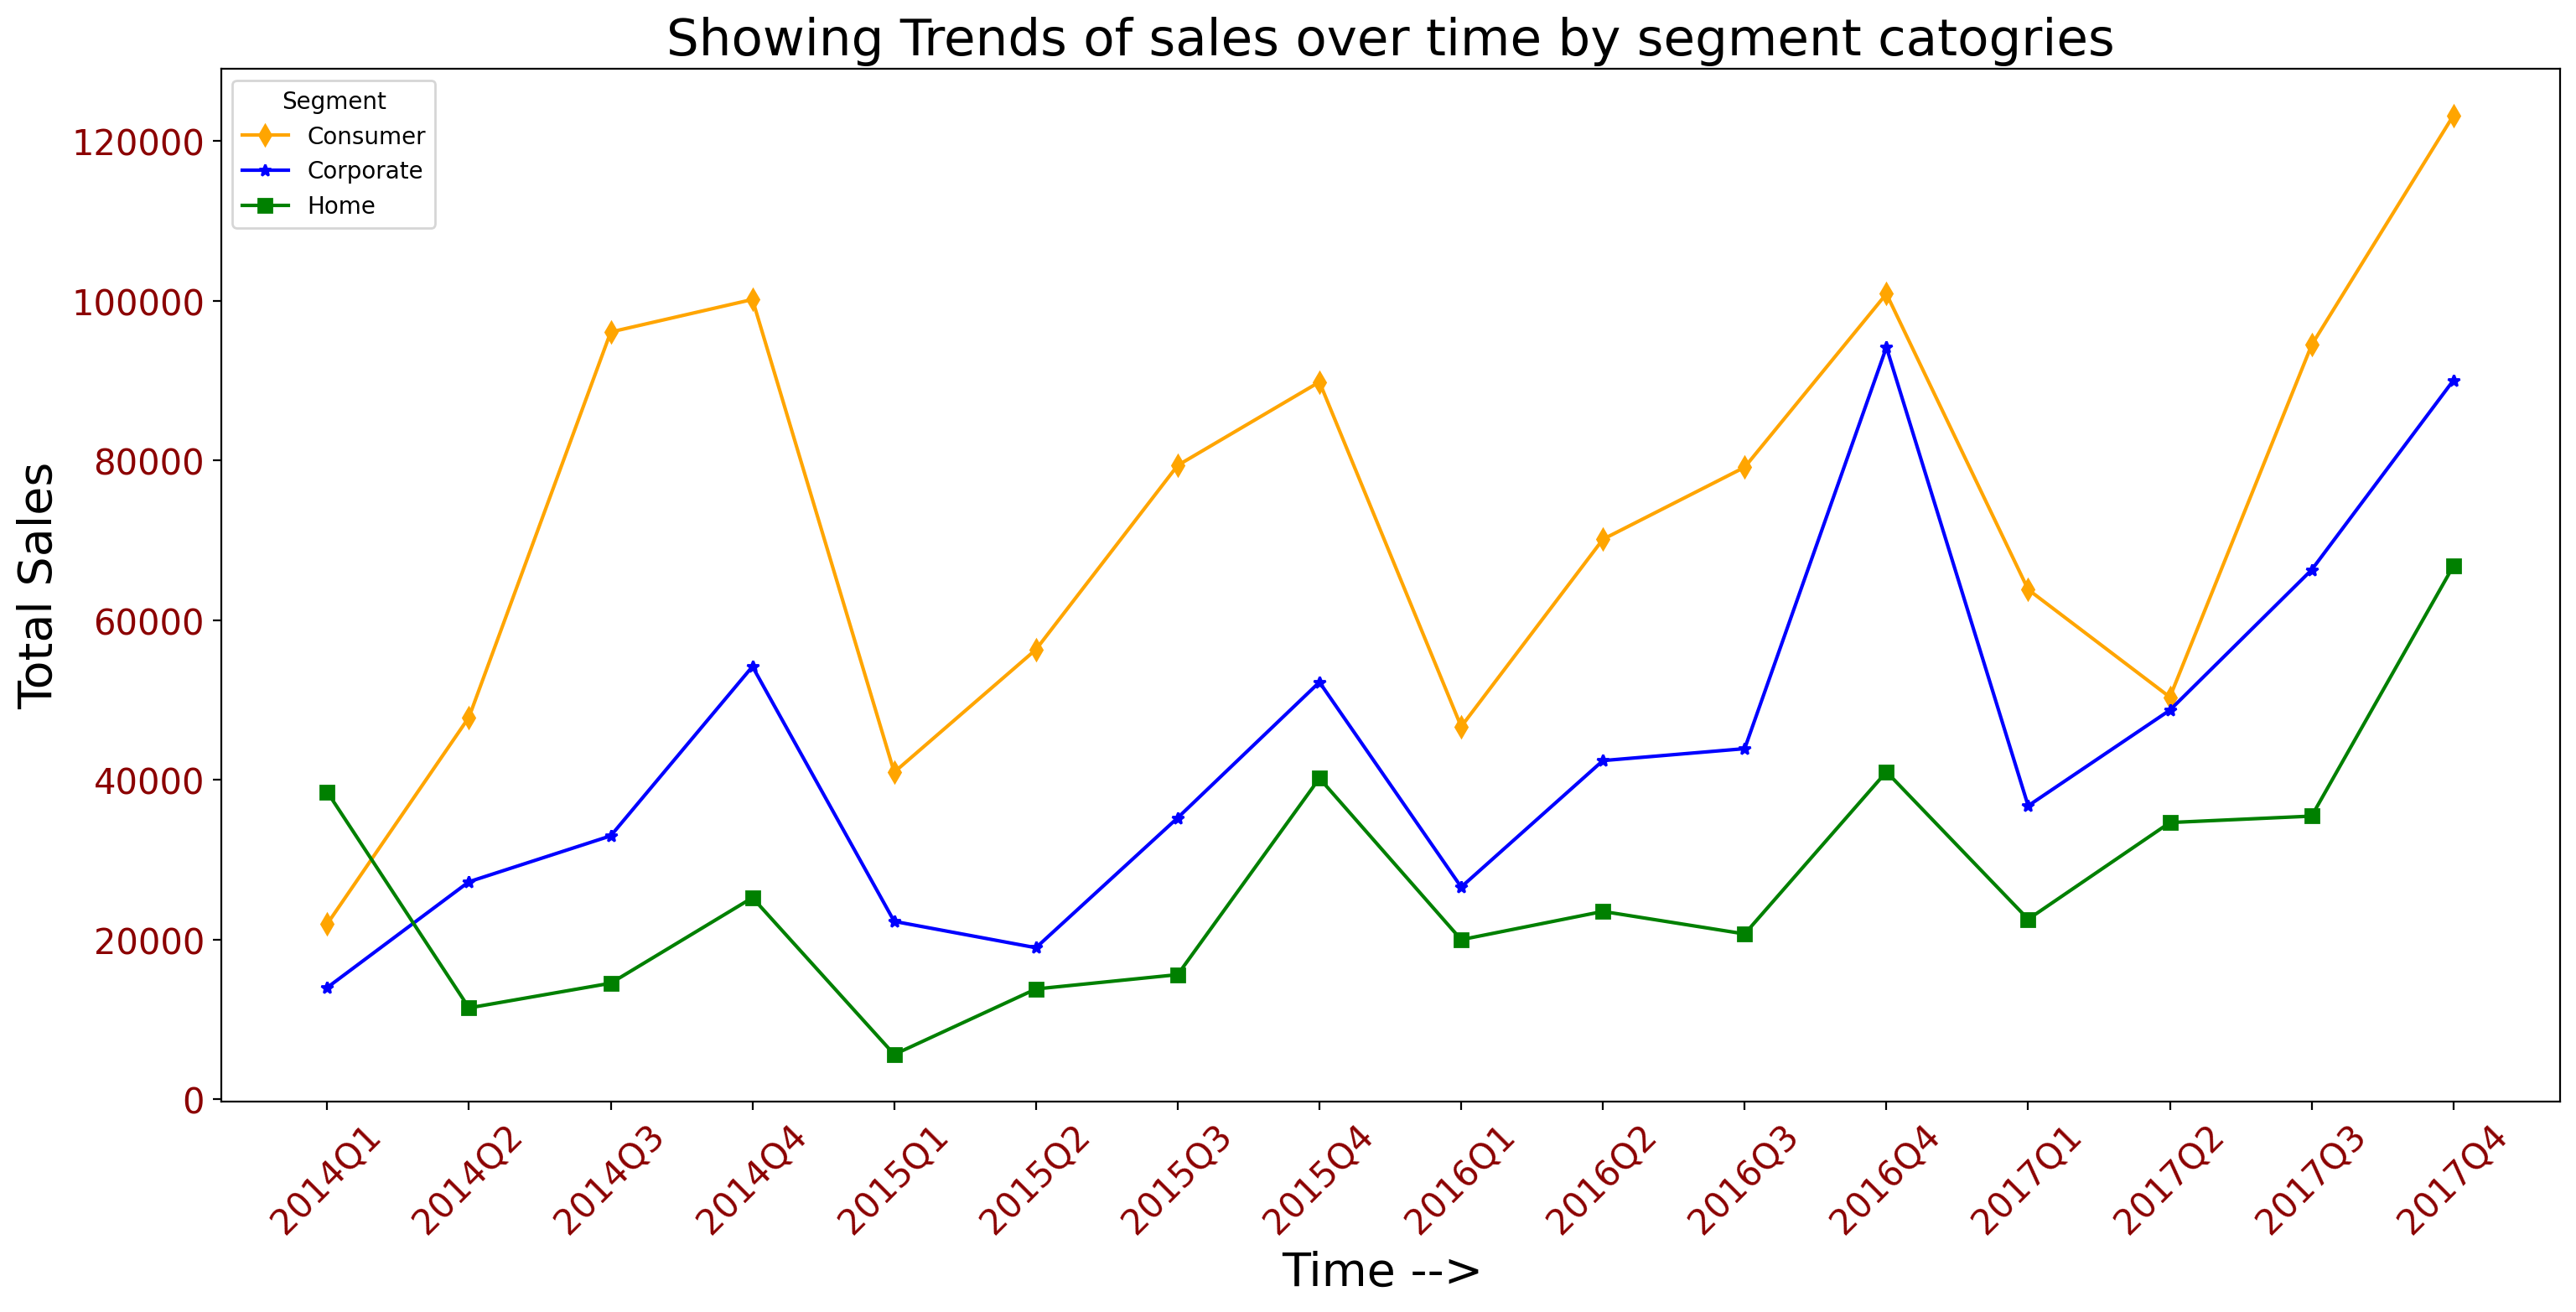

In [208]:
plt.figure(figsize=(18,8),dpi=200)
plt.title('Showing Trends of sales over time by segment catogries',fontsize=22)
plt.ylabel('Total Sales',fontsize=20,color='Black')
plt.xlabel('Time --> ',fontsize=20,color='Black')
# Marker 
plt.plot(crssdata.index,crssdata.Consumer,color='orange',label='Consumer', marker = "d") # dots are represended as Marker 
plt.plot(crssdata.index,crssdata.Corporate,color='blue',label='Corporate', marker = "*",markersize =5) # we can also give marker size 
plt.plot(crssdata.index,crssdata['Home Office'],color='Green',label='Home', marker = "s") # d,*,.,s represents shape  can be found in description

plt.legend(title="Segment",loc='best')
plt.xticks(rotation =45,fontsize=15,color='darkred')
plt.yticks(fontsize=15,color='darkred')
 
plt.show();

In [209]:
crssdata['Home Office']

Order_Date
2014Q1    38490.8260
2014Q2    11442.5940
2014Q3    14537.0518
2014Q4    25245.3400
2015Q1     5609.1076
2015Q2    13814.0260
2015Q3    15608.6340
2015Q4    40207.5012
2016Q1    19986.8330
2016Q2    23525.4790
2016Q3    20706.9560
2016Q4    41016.0690
2017Q1    22547.3074
2017Q2    34658.7035
2017Q3    35465.0900
2017Q4    66791.6300
Name: Home Office, dtype: float64

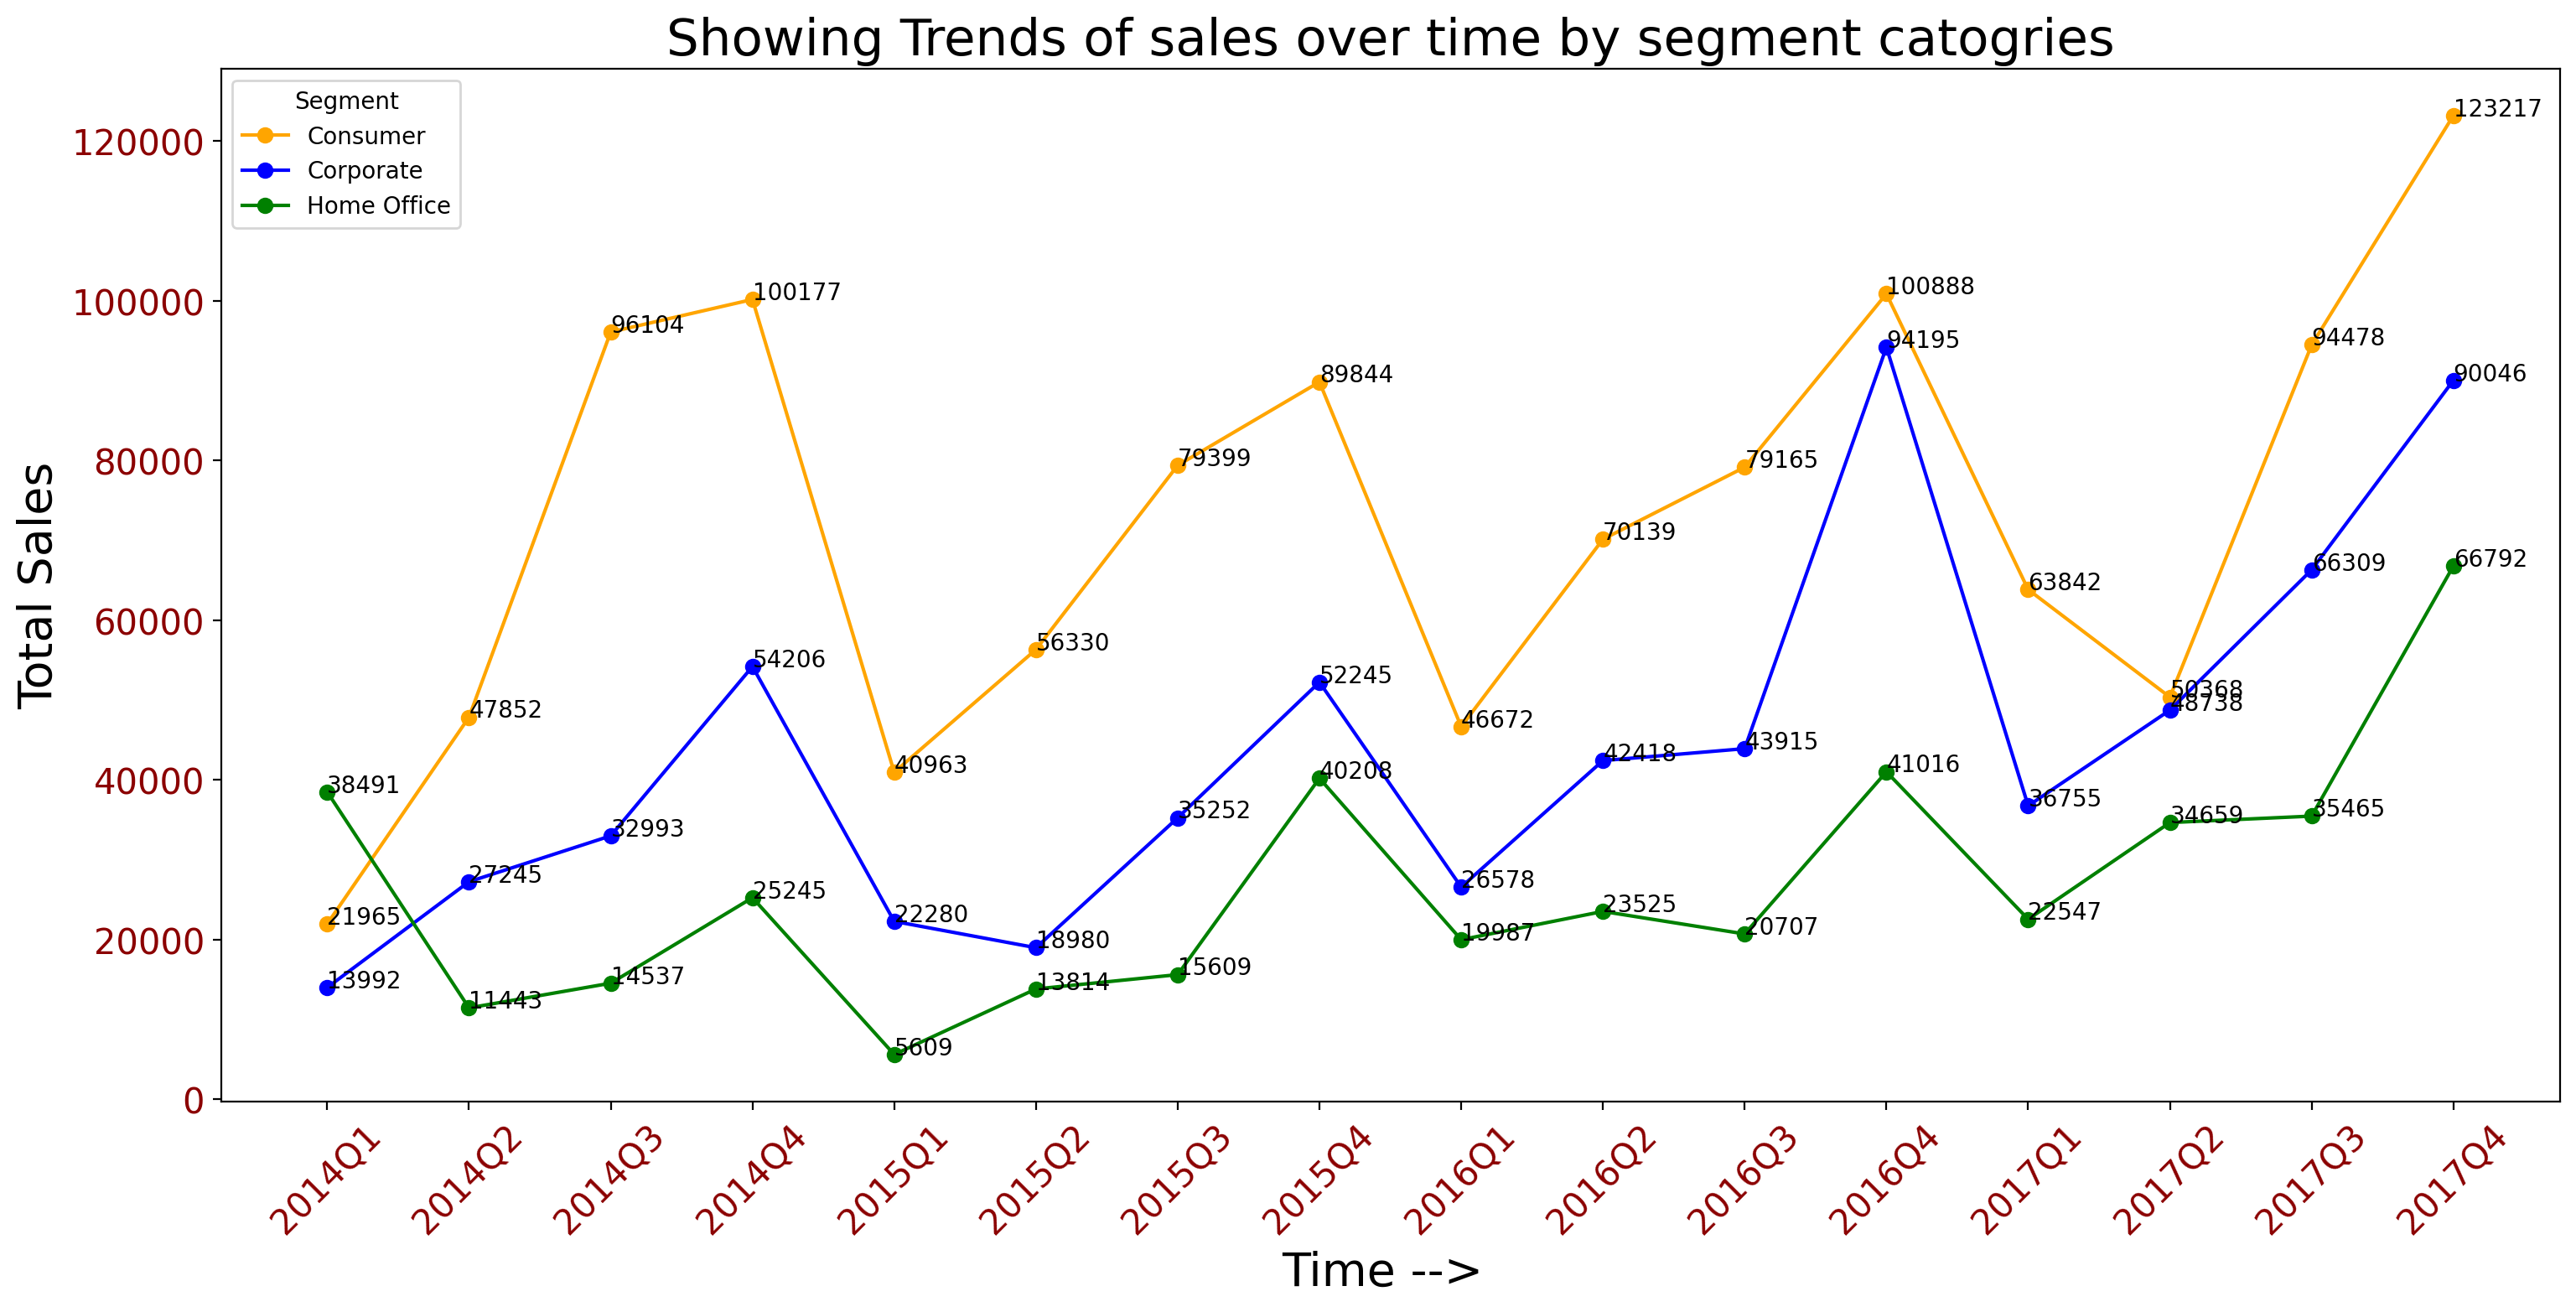

In [221]:
#instread of writing the whole thing we just add the for loop
plt.figure(figsize=(18,8),dpi=200)
plt.title('Showing Trends of sales over time by segment catogries',fontsize=22)

plt.ylabel('Total Sales',fontsize=20,color='Black')
plt.xlabel('Time --> ',fontsize=20,color='Black')

colors=['orange','blue','Green']
for index,every in enumerate(crssdata.columns.to_list()):
    plt.plot(crssdata.index,crssdata[every],label=every,color=colors[index],marker = "o")
    for index, val in zip(crssdata.index,crssdata[every]):
        plt.text(index,val,f'{val:.0f}',fontsize=10, ha="left", va="baseline")
        
plt.legend(title="Segment",loc='best')
plt.xticks(rotation =45,fontsize=15,color='darkred')
plt.yticks(fontsize=15,color='darkred')
 
plt.show();


In [206]:
crssdata.columns

Index(['Consumer', 'Corporate', 'Home Office'], dtype='object', name='Segment')

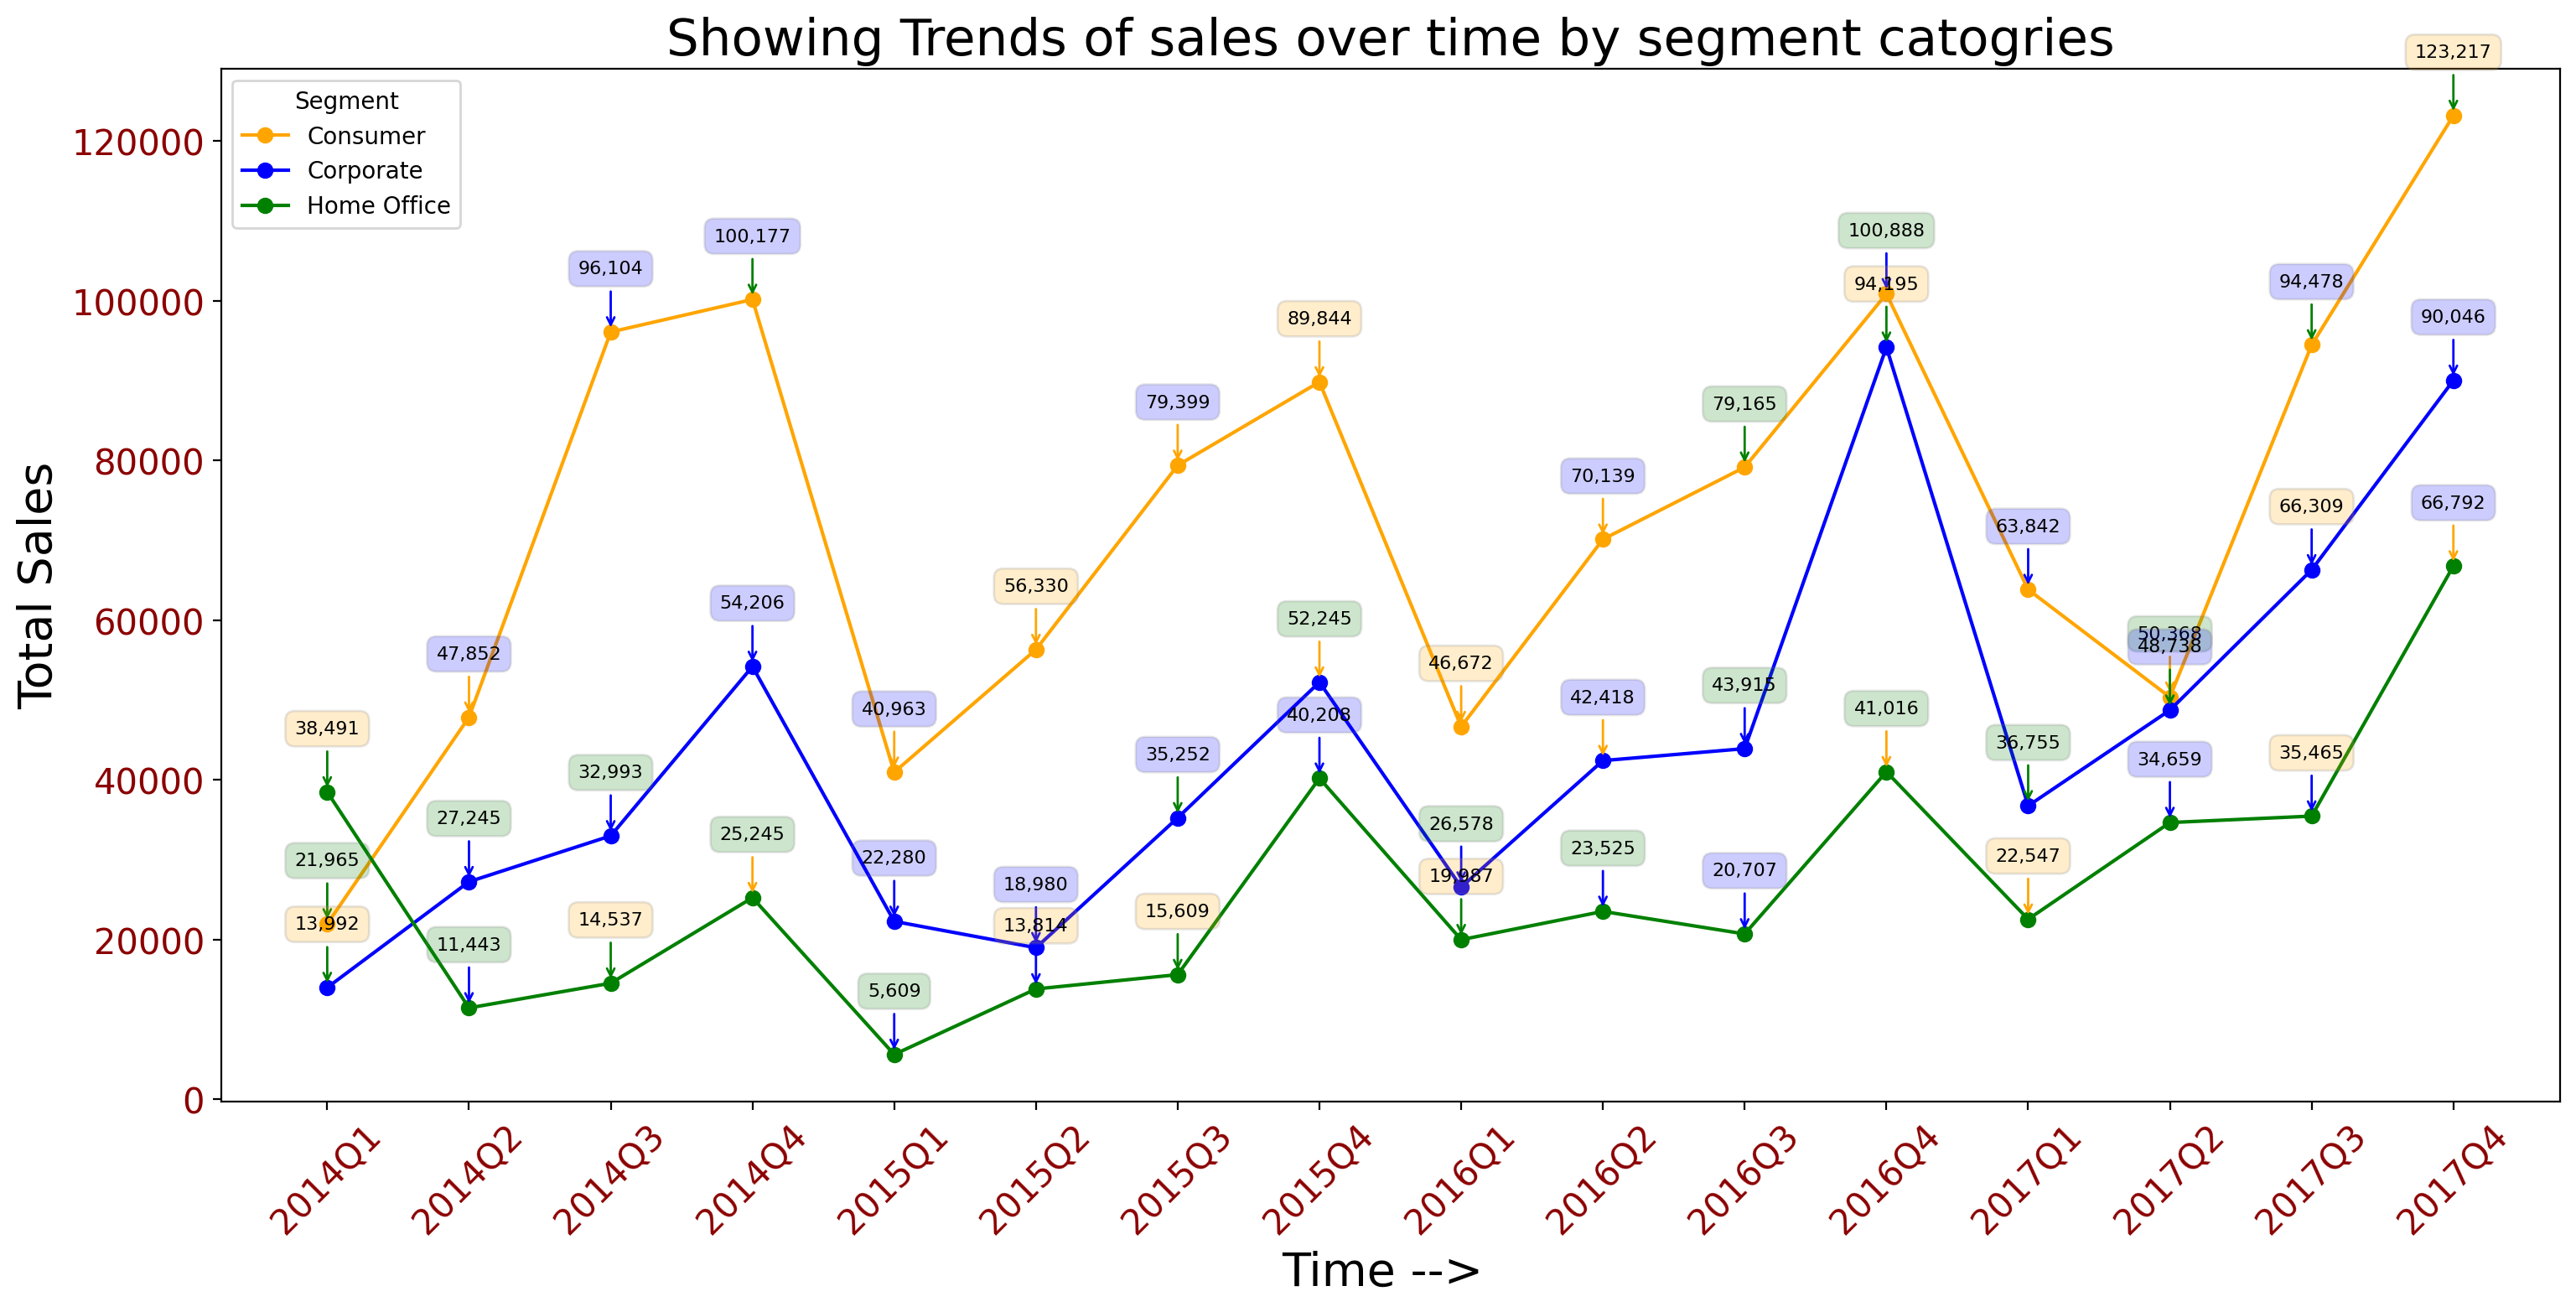

In [250]:
#instread of writing the whole thing we just add the for loop
import random as rd
plt.figure(figsize=(18,8),dpi=200)
plt.title('Showing Trends of sales over time by segment catogries',fontsize=22)

plt.ylabel('Total Sales',fontsize=20,color='Black')
plt.xlabel('Time --> ',fontsize=20,color='Black')

colors=['orange','blue','Green']
for index,every in enumerate(crssdata.columns.to_list()):
    plt.plot(crssdata.index,crssdata[every],label=every,color=colors[index],marker = "o")
    for x, y in zip(crssdata.index,crssdata[every]):
         plt.annotate(f"{y:,.0f}",
                     xy=(x, y),                # point
                     xytext=(0, 25),           # label offset (x=0, y=10 pixels above)
                     textcoords="offset points",
                     ha="center", fontsize=8,
                     arrowprops=dict(arrowstyle="->", color=colors[random.randint(0,2)],lw=1),
                    bbox=dict(facecolor=colors[random.randint(0,2)],alpha=0.2, edgecolor='gray', 
                              boxstyle='round',pad=0.5)
                    )
        
plt.legend(title="Segment",loc='best')
plt.xticks(rotation =45,fontsize=15,color='darkred')
plt.yticks(fontsize=15,color='darkred')
 
plt.show();


# Area chat 

## Basically area chat is similar to line chat but betwenn are is filled with colours 


 #### plt.fill_between(sales_agg.index.astype(str), sales_agg[col], color=color_list[idx], alpha=0.2)


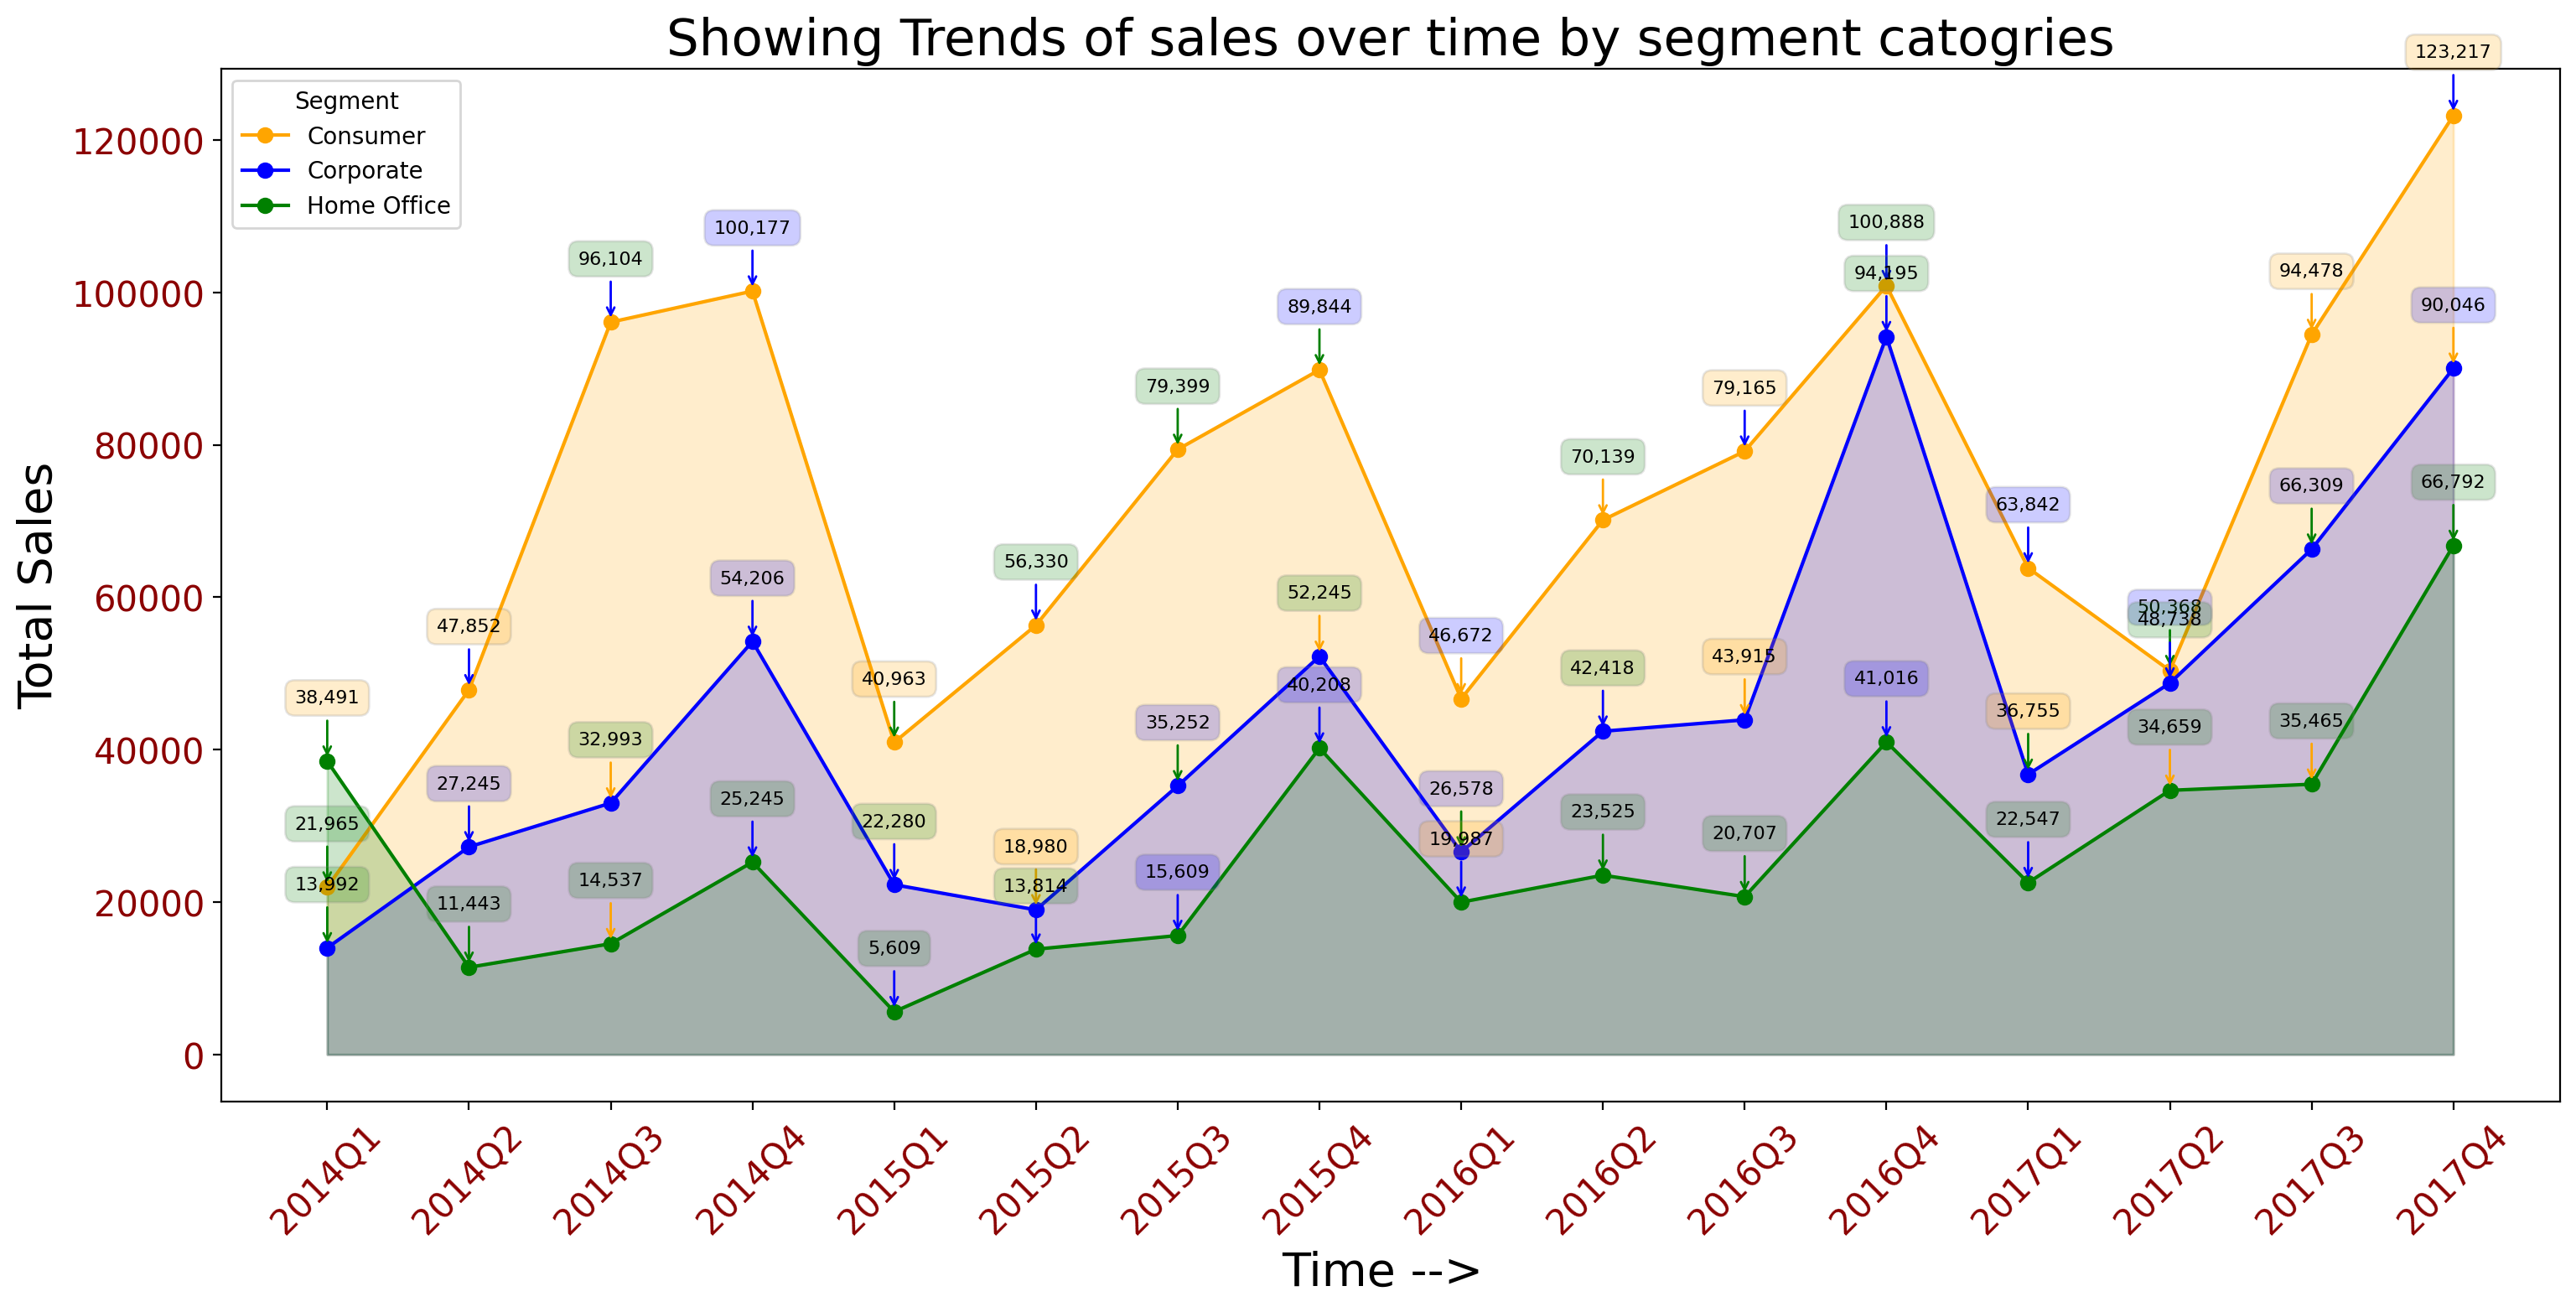

In [257]:
##instread of writing the whole thing we just add the for loop
import random as rd
plt.figure(figsize=(18,8),dpi=200)
plt.title('Showing Trends of sales over time by segment catogries',fontsize=22)

plt.ylabel('Total Sales',fontsize=20,color='Black')
plt.xlabel('Time --> ',fontsize=20,color='Black')

colors=['orange','blue','Green']
for index,every in enumerate(crssdata.columns.to_list()):
    plt.plot(crssdata.index,crssdata[every],label=every,color=colors[index],marker = "o")
    plt.fill_between(crssdata.index,crssdata[every],color=colors[index],alpha=0.2) #here alpha relates trasperency 
    for x, y in zip(crssdata.index,crssdata[every]):
         plt.annotate(f"{y:,.0f}",
                     xy=(x, y),                # point
                     xytext=(0, 25),           # label offset (x=0, y=10 pixels above)
                     textcoords="offset points",
                     ha="center", fontsize=8,
                     arrowprops=dict(arrowstyle="->", color=colors[random.randint(0,2)],lw=1),
                    bbox=dict(facecolor=colors[random.randint(0,2)],alpha=0.2, edgecolor='gray', 
                              boxstyle='round',pad=0.5)
                    )
        
plt.legend(title="Segment",loc='best')
plt.xticks(rotation =45,fontsize=15,color='darkred')
plt.yticks(fontsize=15,color='darkred')
 
plt.show();


In [29]:
aggtble

Region
Central    215.8
East       238.3
South      241.8
West       226.5
Name: Sales, dtype: float64

In [36]:
# pie charts 
# contain a numerical column and one catogorical column
# region wise sales
aggtble=round(store_df.groupby('Region')[['Sales']].agg('sum')/store_df.Sales.sum()*100,1)
aggtble


,Sales
Region,
Central,21.8
East,29.5
South,17.1
West,31.6


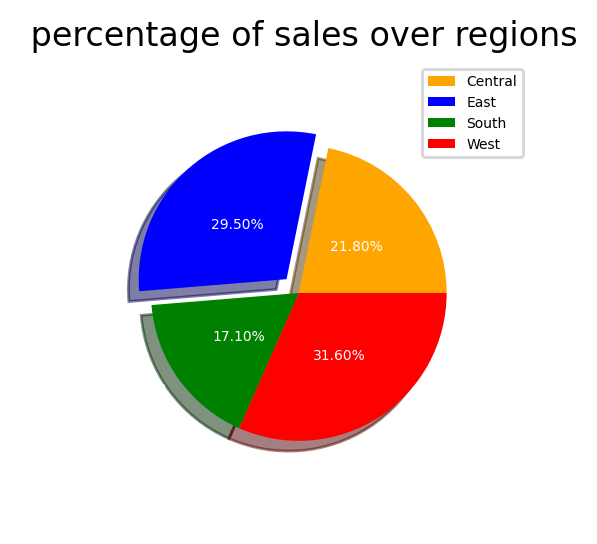

In [123]:
plt.figure(figsize=(3,3),dpi=200)
plt.title(" percentage of sales https://smartinterviews.in/leaderboard/1over regions")

plt.pie(aggtble.Sales,labels=aggtble.index,radius=0.8,autopct="%.2f%%",textprops={'fontsize': 5,'color':'white'},explode=[0,0.1,0,0],colors=['orange','blue','Green','red'],pctdistance=0.5,shadow=True ) 
# explode rotates through anti cloclk wise direction
#psc distance is distance from radious 
plt.legend(loc='best', fontsize=5)


plt.show();

# Bar chat

In [175]:
# Data preperation for the bar chat 
bardata=store_df.groupby('Category')[['Profit']].agg('sum')
bardata

,Profit
Category,
Furniture,18451.2728
Office Supplies,122490.8008
Technology,145454.9481


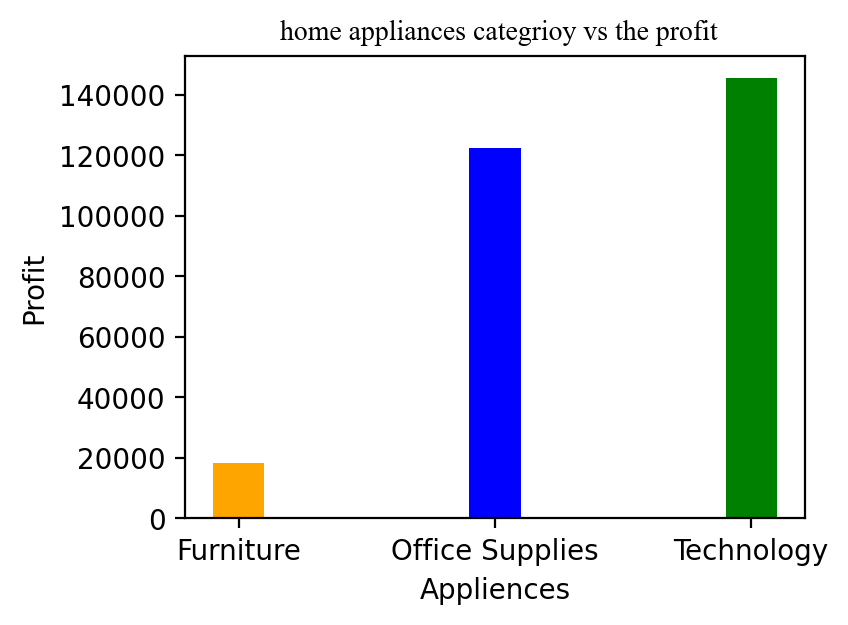

In [176]:

plt.figure(figsize=(4,3),dpi=200)
plt.title(" home appliances categrioy vs the profit",fontsize=8,font='Times New Roman')
plt.xlabel("Appliences")
plt.ylabel("Profit")

plt.bar(x=bardata.index,height=bardata.Profit,width=0.2,color=['orange','Blue','green'])
plt.show();

## horizontal  barchat

<Figure size 1200x800 with 0 Axes>

Text(0.5, 1.0, ' home appliances categrioy and their sun catogries  vs the profit')

Text(0, 0.5, 'Appliences')

Text(0.5, 0, 'Profit')

<BarContainer object of 3 artists>

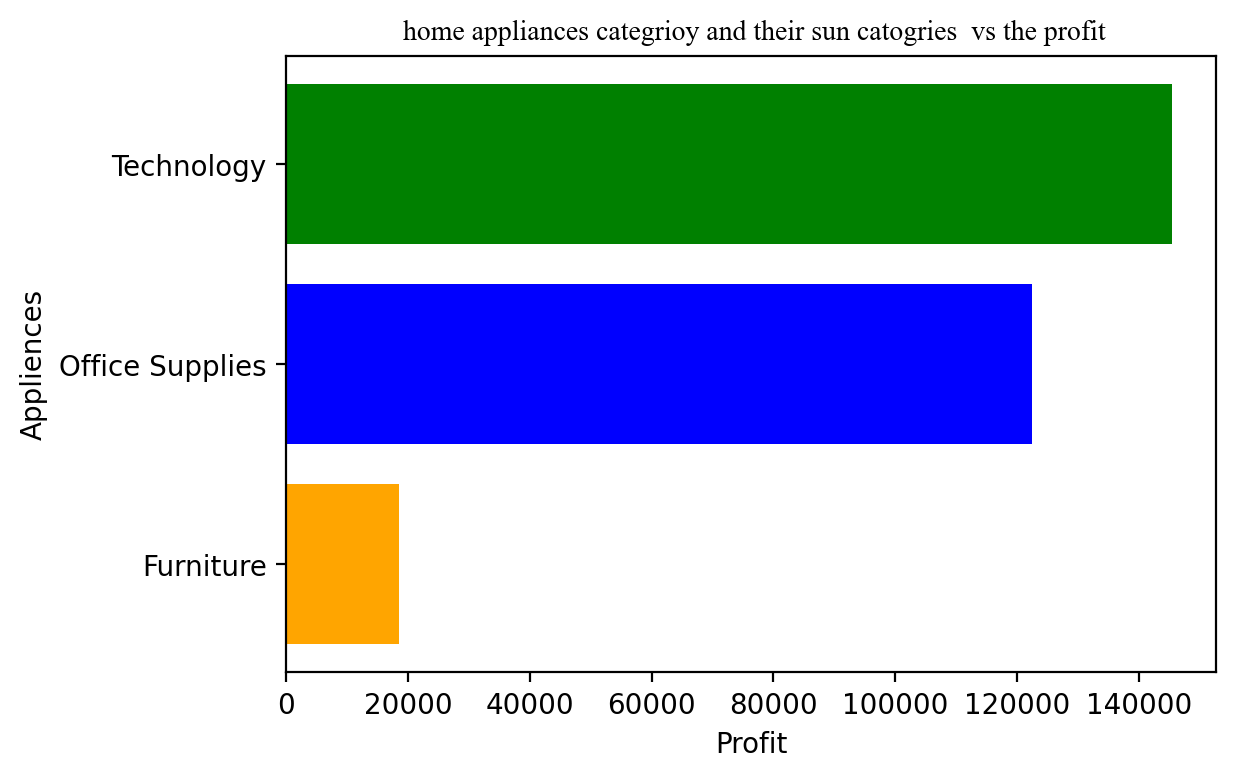

In [184]:
plt.figure(figsize=(6,4),dpi=200)
plt.title(" home appliances categrioy and their sun catogries  vs the profit",fontsize=8,font='Times New Roman')
plt.ylabel("Appliences")
plt.xlabel("Profit")
plt.barh(y=bardata.index,width=bardata.Profit,color=['orange','Blue','green'])
plt.show()

## Grouped bar chats


In [ ]:
 # for the group bars and the stacked bars the is not directly works with olt we we definion direct ploting techniguwe


In [206]:
# grouped bar chat is simillar to bar chat here there are 2 catagorical and 1 numerical column present 
#data for catogory and sub catogiry
#group chat basically directly not available in ply directly we 
bardata=store_df.groupby(["Segment", "Region"])['Sales'].agg('sum').unstack()
bardata

Region,Central,East,South,West
Segment,,,,
Consumer,252031.4340,350908.167,195580.9710,362880.7730
Corporate,157995.8128,200409.347,121885.9325,225855.2745
Home Office,91212.6440,127463.726,74255.0015,136721.7770


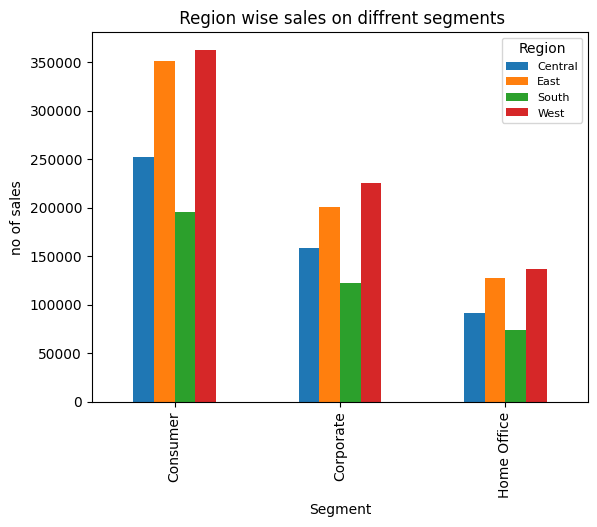

In [228]:
bardata.plot(kind='bar',use_index ='Category')
plt.title(" Region wise sales on diffrent segments")
plt.ylabel("no of sales")
plt.legend(fontsize=8,title='Region')
plt.show();

## stacked bar 

In [229]:
# stacked bar is similar to these bars, it is used to represents the how sub categoreical values are contributing in total value gedata


In [330]:
# we want to find the subgroups 

g3=store_df.groupby(['Ship Mode','Segment'])['Profit'].sum().unstack()
g3

Segment,Consumer,Corporate,Home Office
Ship Mode,,,
First Class,21374.0436,14464.4724,13131.3239
Same Day,9874.2054,1818.1418,4199.4117
Second Class,24946.9112,18225.7131,14274.0111
Standard Class,77924.0490,57470.8067,28693.9318


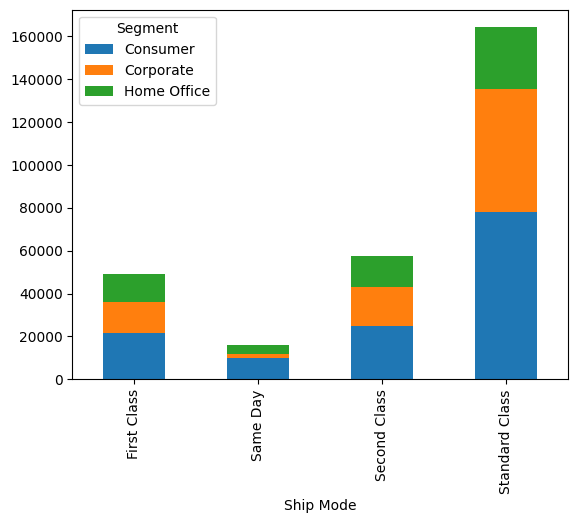

In [331]:

g3.plot(kind='bar',stacked=True,use_index =True)
plt.show();


<Axes: title={'center': 'Horizontal plot region vs cat vs profit'}, ylabel='Ship Mode'>

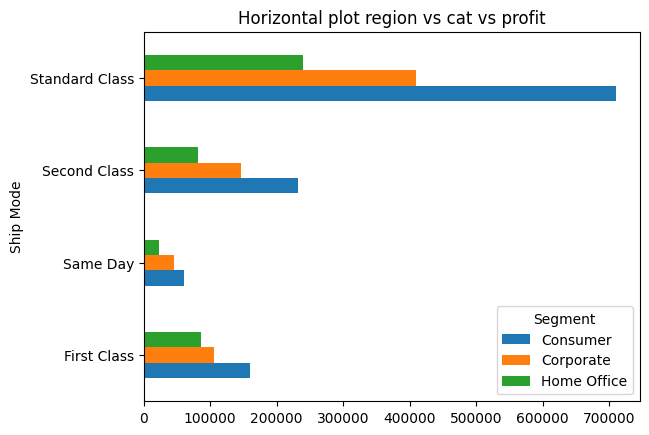

In [290]:
g3.plot(kind='barh',title='Horizontal plot region vs cat vs profit')

## Sub-plots

In [268]:
aggd1

Category
Furniture          741999.7953
Office Supplies    719047.0320
Technology         836154.0330
Name: Sales, dtype: float64

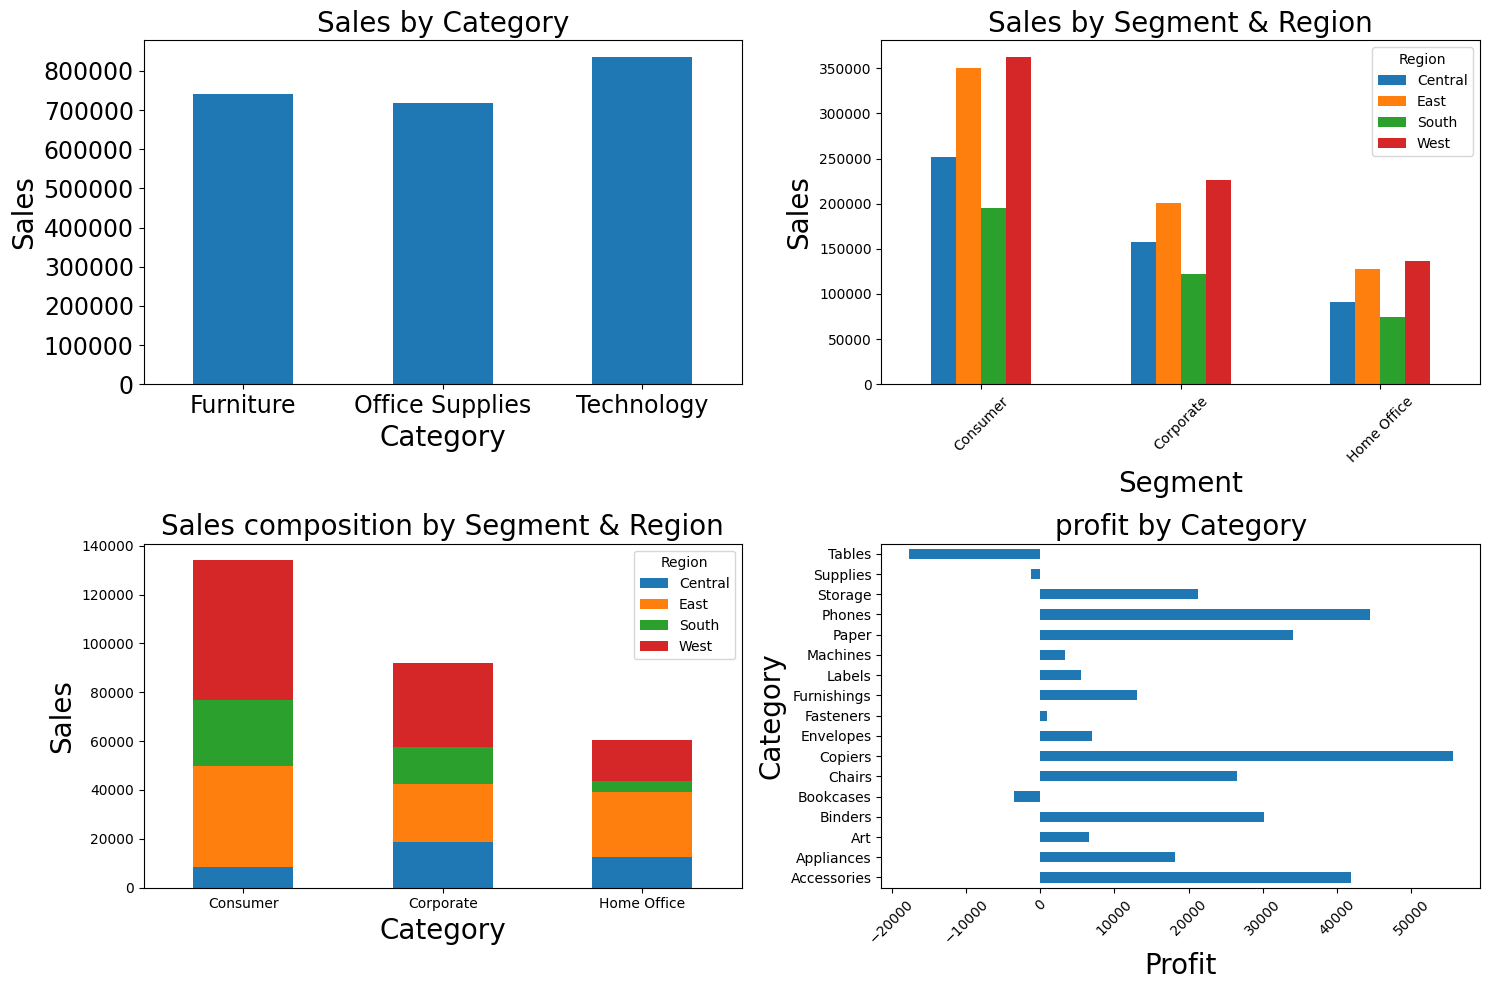

In [351]:
# if you want to display the multiple plots in same co we use the sub-plots

fig,axes=plt.subplots(2,2,figsize=(15,10)) #it is a tuple contain returins fig and axes  info so we use axis to plot a certain graph by those info

# 1. Vertical Bar Chart -> Sales by Category
aggd1=store_df.groupby('Category')['Sales'].sum()
aggd1.plot(kind='bar',ax=axes[0][0],fontsize=17,)
axes[0][0].set_title("Sales by Category",fontsize=20)
axes[0][0].set_xlabel("Category",fontsize=20)
axes[0][0].set_ylabel("Sales",fontsize=20)
axes[0][0].tick_params(axis="x", rotation=0)

# 2. Grouped Bar Chart -> Sales by Segment & Regionaggd1=store_df.groupby('Category')['Sales'].sum()
bardata=store_df.groupby(["Segment", "Region"])['Sales'].agg('sum').unstack()
bardata.plot(kind='bar',ax=axes[0][1])
axes[0][1].set_title("Sales by Segment & Region",fontsize=20)
axes[0][1].set_xlabel("Segment",fontsize=20)
axes[0][1].set_ylabel("Sales",fontsize=20)
axes[0][1].tick_params(axis="x", rotation=45)
# 3. Stacked Bar Chart -> Sales composition by Segment & Region
stack=store_df.groupby(["Segment", "Region"])['Profit'].agg('sum').unstack()
stack.plot(kind='bar',stacked=True,ax=axes[1][0])
axes[1][0].set_title("Sales composition by Segment & Region",fontsize=20)
axes[1][0].set_xlabel("Category",fontsize=20)
axes[1][0].set_ylabel("Sales",fontsize=20)
axes[1][0].tick_params(axis="x", rotation=0)

# 4. Horizontal Bar Chart -> Profit by Sub-Category
agg=store_df.groupby('Sub-Category')['Profit'].sum()
agg.plot(kind='barh',ax=axes[1][1])
axes[1][1].set_title("profit by Category",fontsize=20)
axes[1][1].set_xlabel("Profit",fontsize=20)
axes[1][1].set_ylabel("Category",fontsize=20)
axes[1][1].tick_params(axis="x", rotation=45)
plt.tight_layout() #allows to

plt.show();

# 5. Histogram


In [353]:
# hisogram is also bar like structure used to repe]resent the numerical data

store_df.Quantity.value_counts()

Quantity
3     2409
2     2402
5     1230
4     1191
1      899
7      606
6      572
9      258
8      257
10      57
11      34
14      29
13      27
12      23
Name: count, dtype: int64

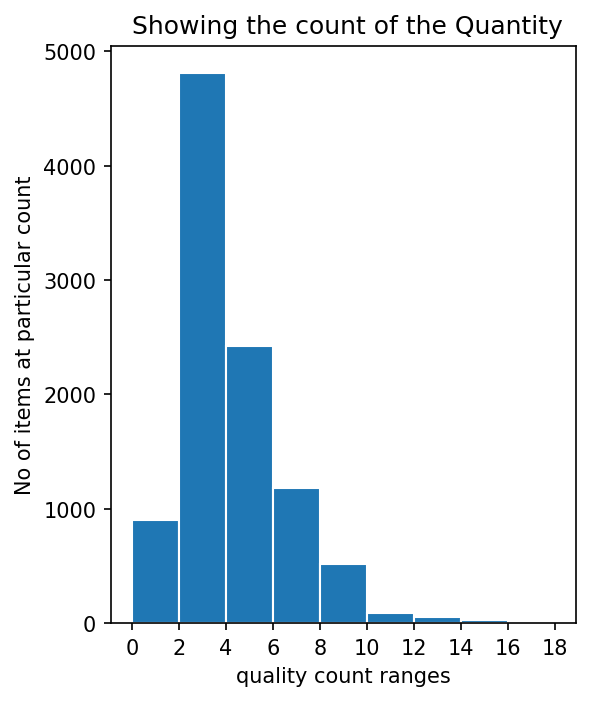

In [373]:
plt.figure(figsize=(4,5),dpi=150)
plt.title(" Showing the count of the Quantity")
plt.hist(store_df.Quantity,bins=np.arange(0,20,2),edgecolor='white',width=2)
plt.xticks(np.arange(0,20,2))
plt.xlabel('quality count ranges')
plt.ylabel('No of items at particular count')
plt.show();

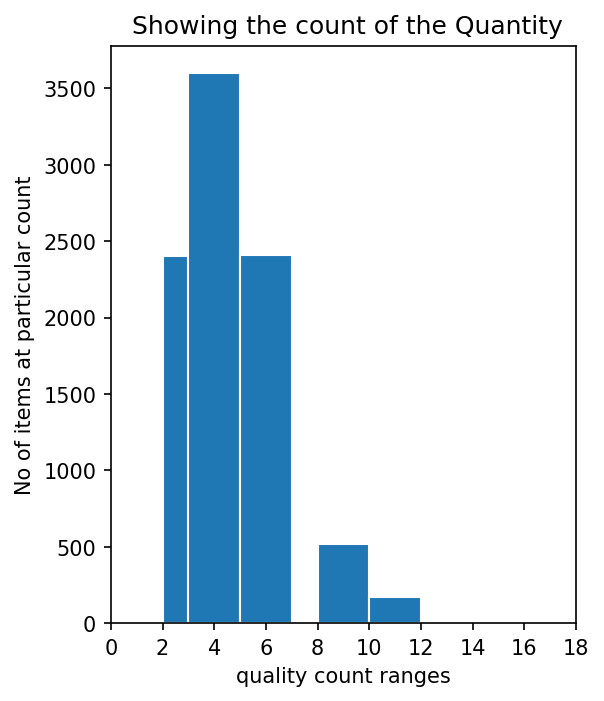

In [379]:
#we can also define bins by hand 
plt.figure(figsize=(4,5),dpi=150)
plt.title(" Showing the count of the Quantity")
plt.hist(store_df.Quantity,bins=[2,3,5,8,10,15],edgecolor='white',width=2)
plt.xticks(np.arange(0,20,2))
plt.xlabel('quality count ranges')
plt.ylabel('No of items at particular count')
plt.show();

## pd.cut used to evenly distribute certain values in to indexed bins


<Axes: xlabel='Quantity'>

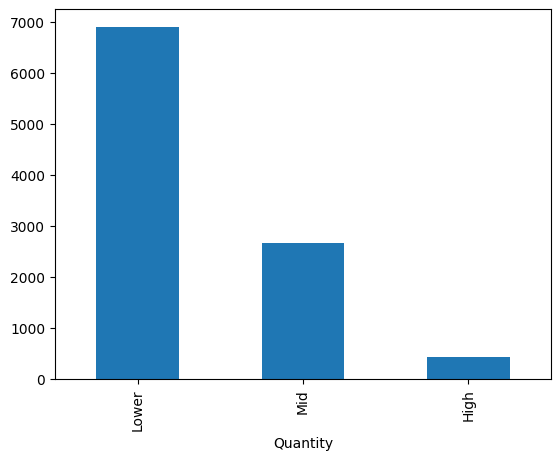

In [390]:
# supporse take quantity only we want to place lables that 0-6 lower ,6-10-mid,10>high so we can achive this by using bins 
table2=pd.cut(store_df.Quantity,bins=[0,4,8,15],labels=['Lower','Mid','High']).value_counts().plot(kind='bar')
table2

# SCATTER PLOT

### used to find the co-relation between the 2 numerical column s
### optinal we can also include a catogorical column



In [392]:
cardf=pd.read_csv(r"C:\Users\chidv\Downloads\Data_sets\exported2.csv")
cardf

,Unnamed: 0,make,fuel_type,aspiration,num_of_doors,body_style,drive_wheels,engine_location,wheel_base,length,...,engine_type,num_of_cylinders,engine_size,fuel_system,compression_ratio,horsepower,peak_rpm,city_mpg,highway_mpg,price
0,1,alfa-romero,gas,std,two,convertible,rwd,front,88.6,168.8,...,dohc,four,130,mpfi,9.0,111,5000,21,27,13495
1,2,alfa-romero,gas,std,two,convertible,rwd,front,88.6,168.8,...,dohc,four,130,mpfi,9.0,111,5000,21,27,16500
2,3,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,171.2,...,ohcv,six,152,mpfi,9.0,154,5000,19,26,16500
3,4,audi,gas,std,four,sedan,fwd,front,99.8,176.6,...,ohc,four,109,mpfi,10.0,102,5500,24,30,13950
4,5,audi,gas,std,four,sedan,4wd,front,99.4,176.6,...,ohc,five,136,mpfi,8.0,115,5500,18,22,17450
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
200,201,volvo,gas,std,four,sedan,rwd,front,109.1,188.8,...,ohc,four,141,mpfi,9.5,114,5400,23,28,16845
201,202,volvo,gas,turbo,four,sedan,rwd,front,109.1,188.8,...,ohc,four,141,mpfi,8.7,160,5300,19,25,19045
202,203,volvo,gas,std,four,sedan,rwd,front,109.1,188.8,...,ohcv,six,173,mpfi,8.8,134,5500,18,23,21485
203,204,volvo,diesel,turbo,four,sedan,rwd,front,109.1,188.8,...,ohc,six,145,idi,23.0,106,4800,26,27,22470


In [406]:
cardf.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 23 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Unnamed: 0         205 non-null    int64  
 1   make               205 non-null    object 
 2   fuel_type          205 non-null    object 
 3   aspiration         205 non-null    object 
 4   num_of_doors       205 non-null    object 
 5   body_style         205 non-null    object 
 6   drive_wheels       205 non-null    object 
 7   engine_location    205 non-null    object 
 8   wheel_base         205 non-null    float64
 9   length             205 non-null    float64
 10  width              205 non-null    float64
 11  height             205 non-null    float64
 12  curb_weight        205 non-null    int64  
 13  engine_type        205 non-null    object 
 14  num_of_cylinders   205 non-null    object 
 15  engine_size        205 non-null    int64  
 16  fuel_system        205 non

In [407]:
cardf.peak_rpm=pd.to_numeric(cardf.peak_rpm,errors='coerce')
cardf.peak_rpm=cardf.peak_rpm.fillna(0)
cardf.price=pd.to_numeric(cardf.price,errors='coerce')
cardf.price=cardf.price.fillna(0)
cardf.horsepower=pd.to_numeric(cardf.horsepower,errors='coerce')
cardf.horsepower=cardf.horsepower.fillna(0)

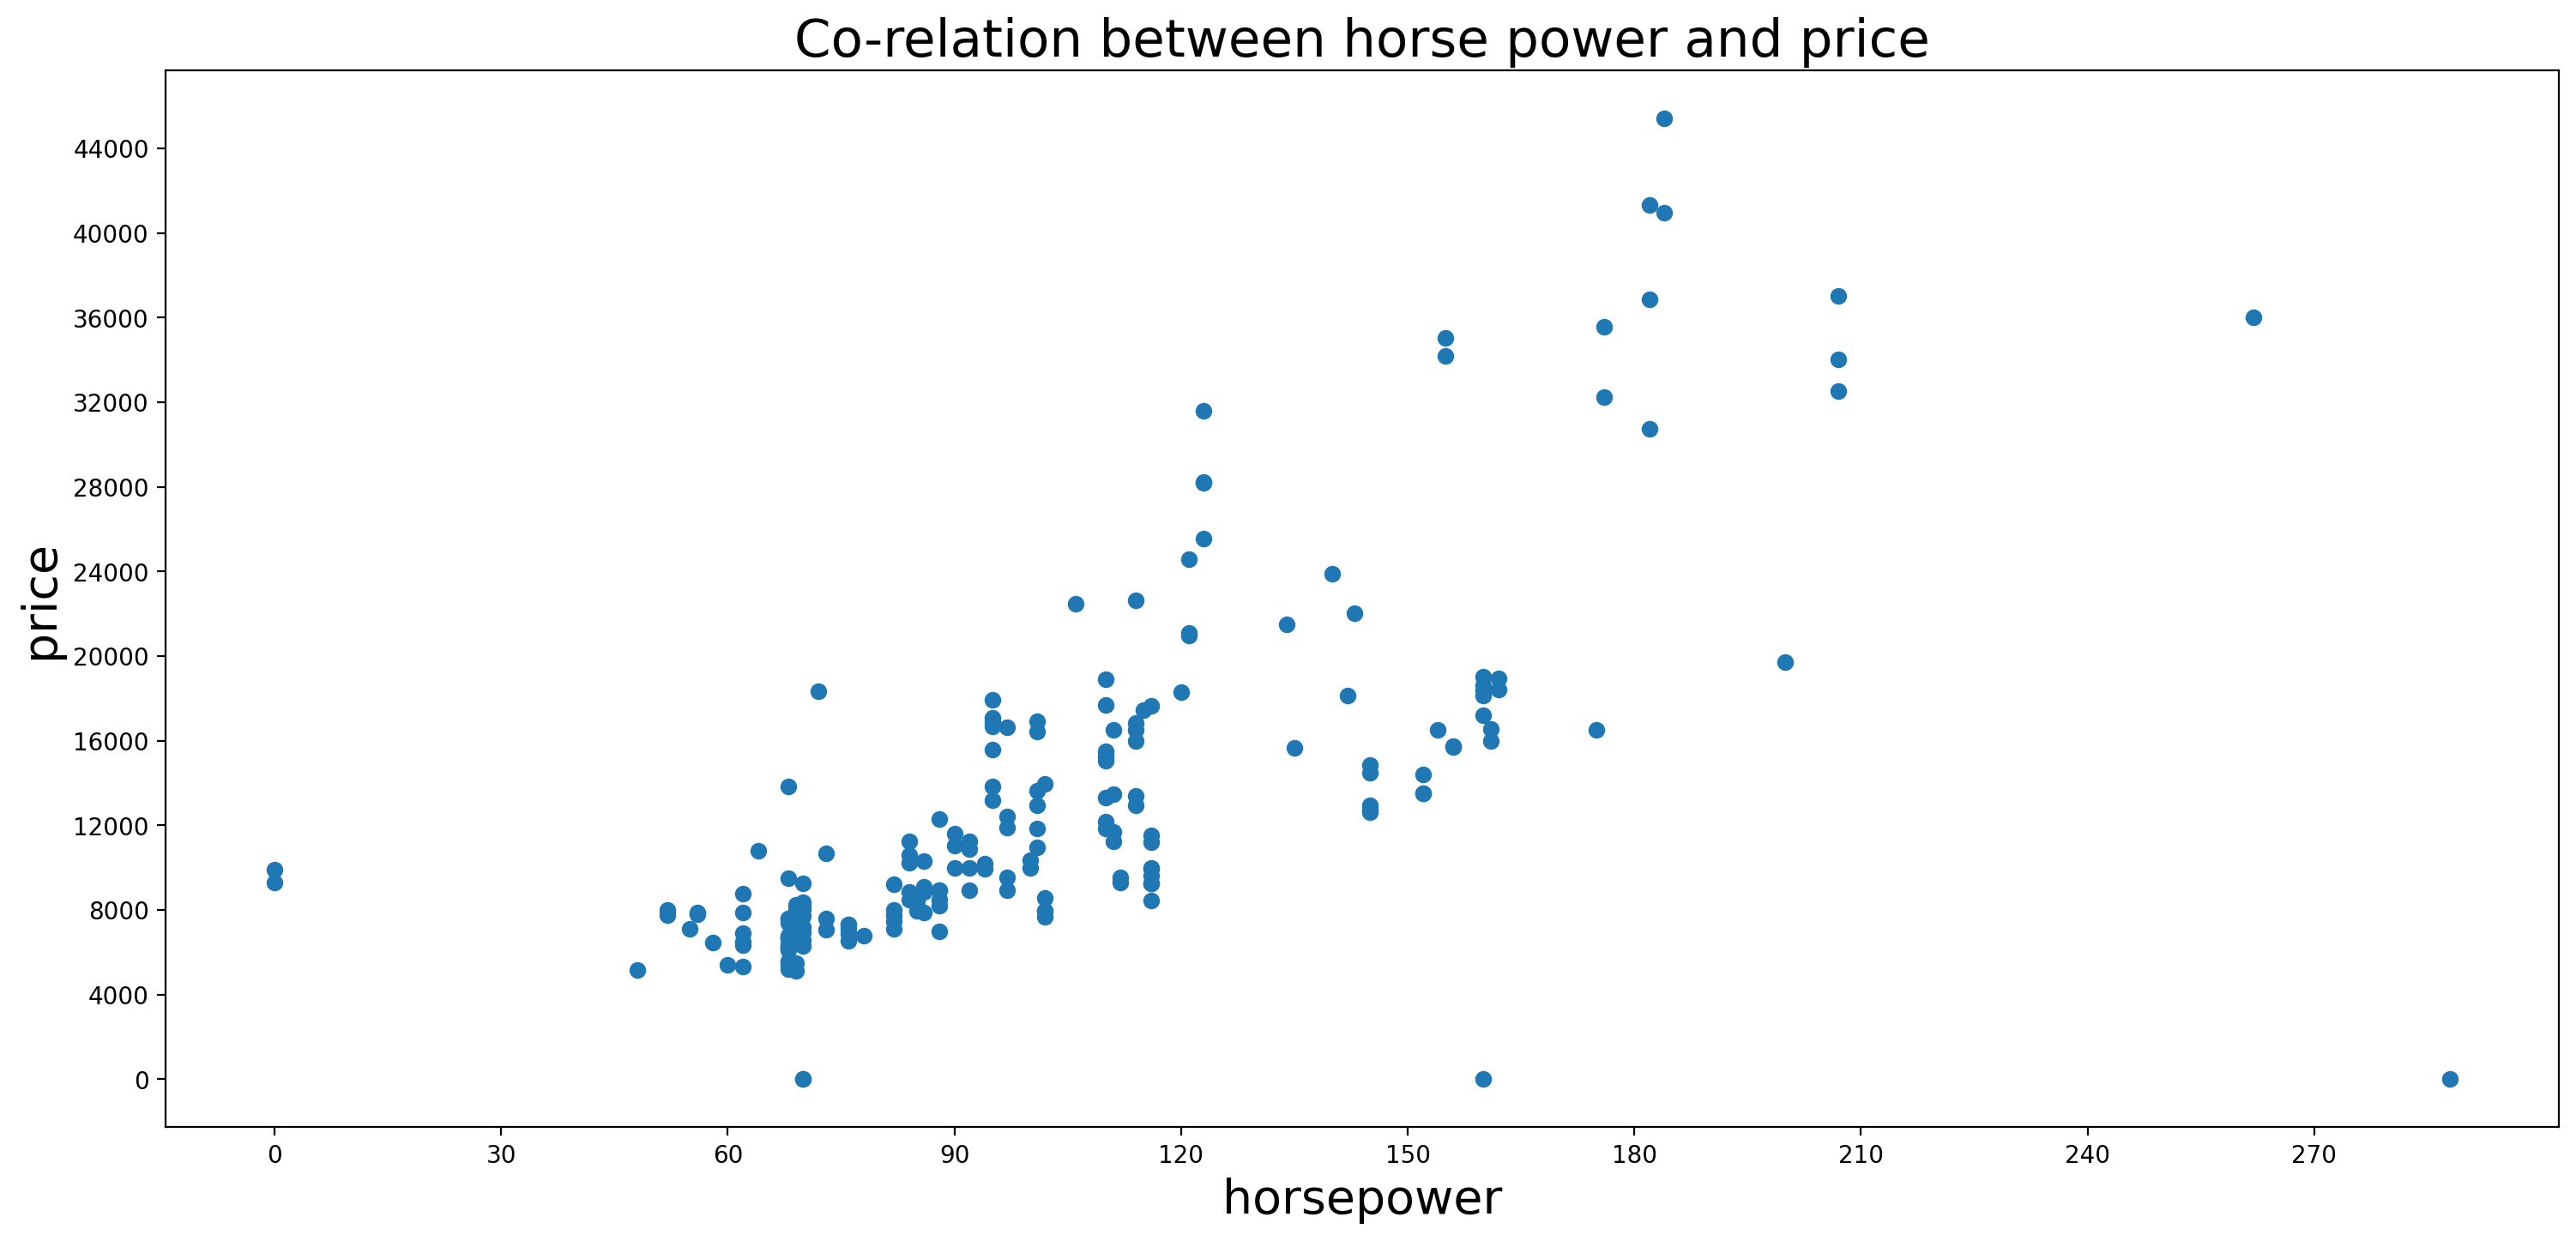

In [424]:
# shows how data is distributed 1 numeric column
plt.figure(figsize=(18,8),dpi=200)
plt.title('Co-relation between horse power and price',fontsize=22)
plt.xticks(np.arange(0,300,30))
plt.yticks(np.arange(0,55000,4000))
plt.ylabel('price',fontsize=20,color='Black')
plt.xlabel('horsepower',fontsize=20,color='Black')
plt.scatter(cardf.horsepower,cardf.price,)
plt.show();

## comparing 3 numeric values

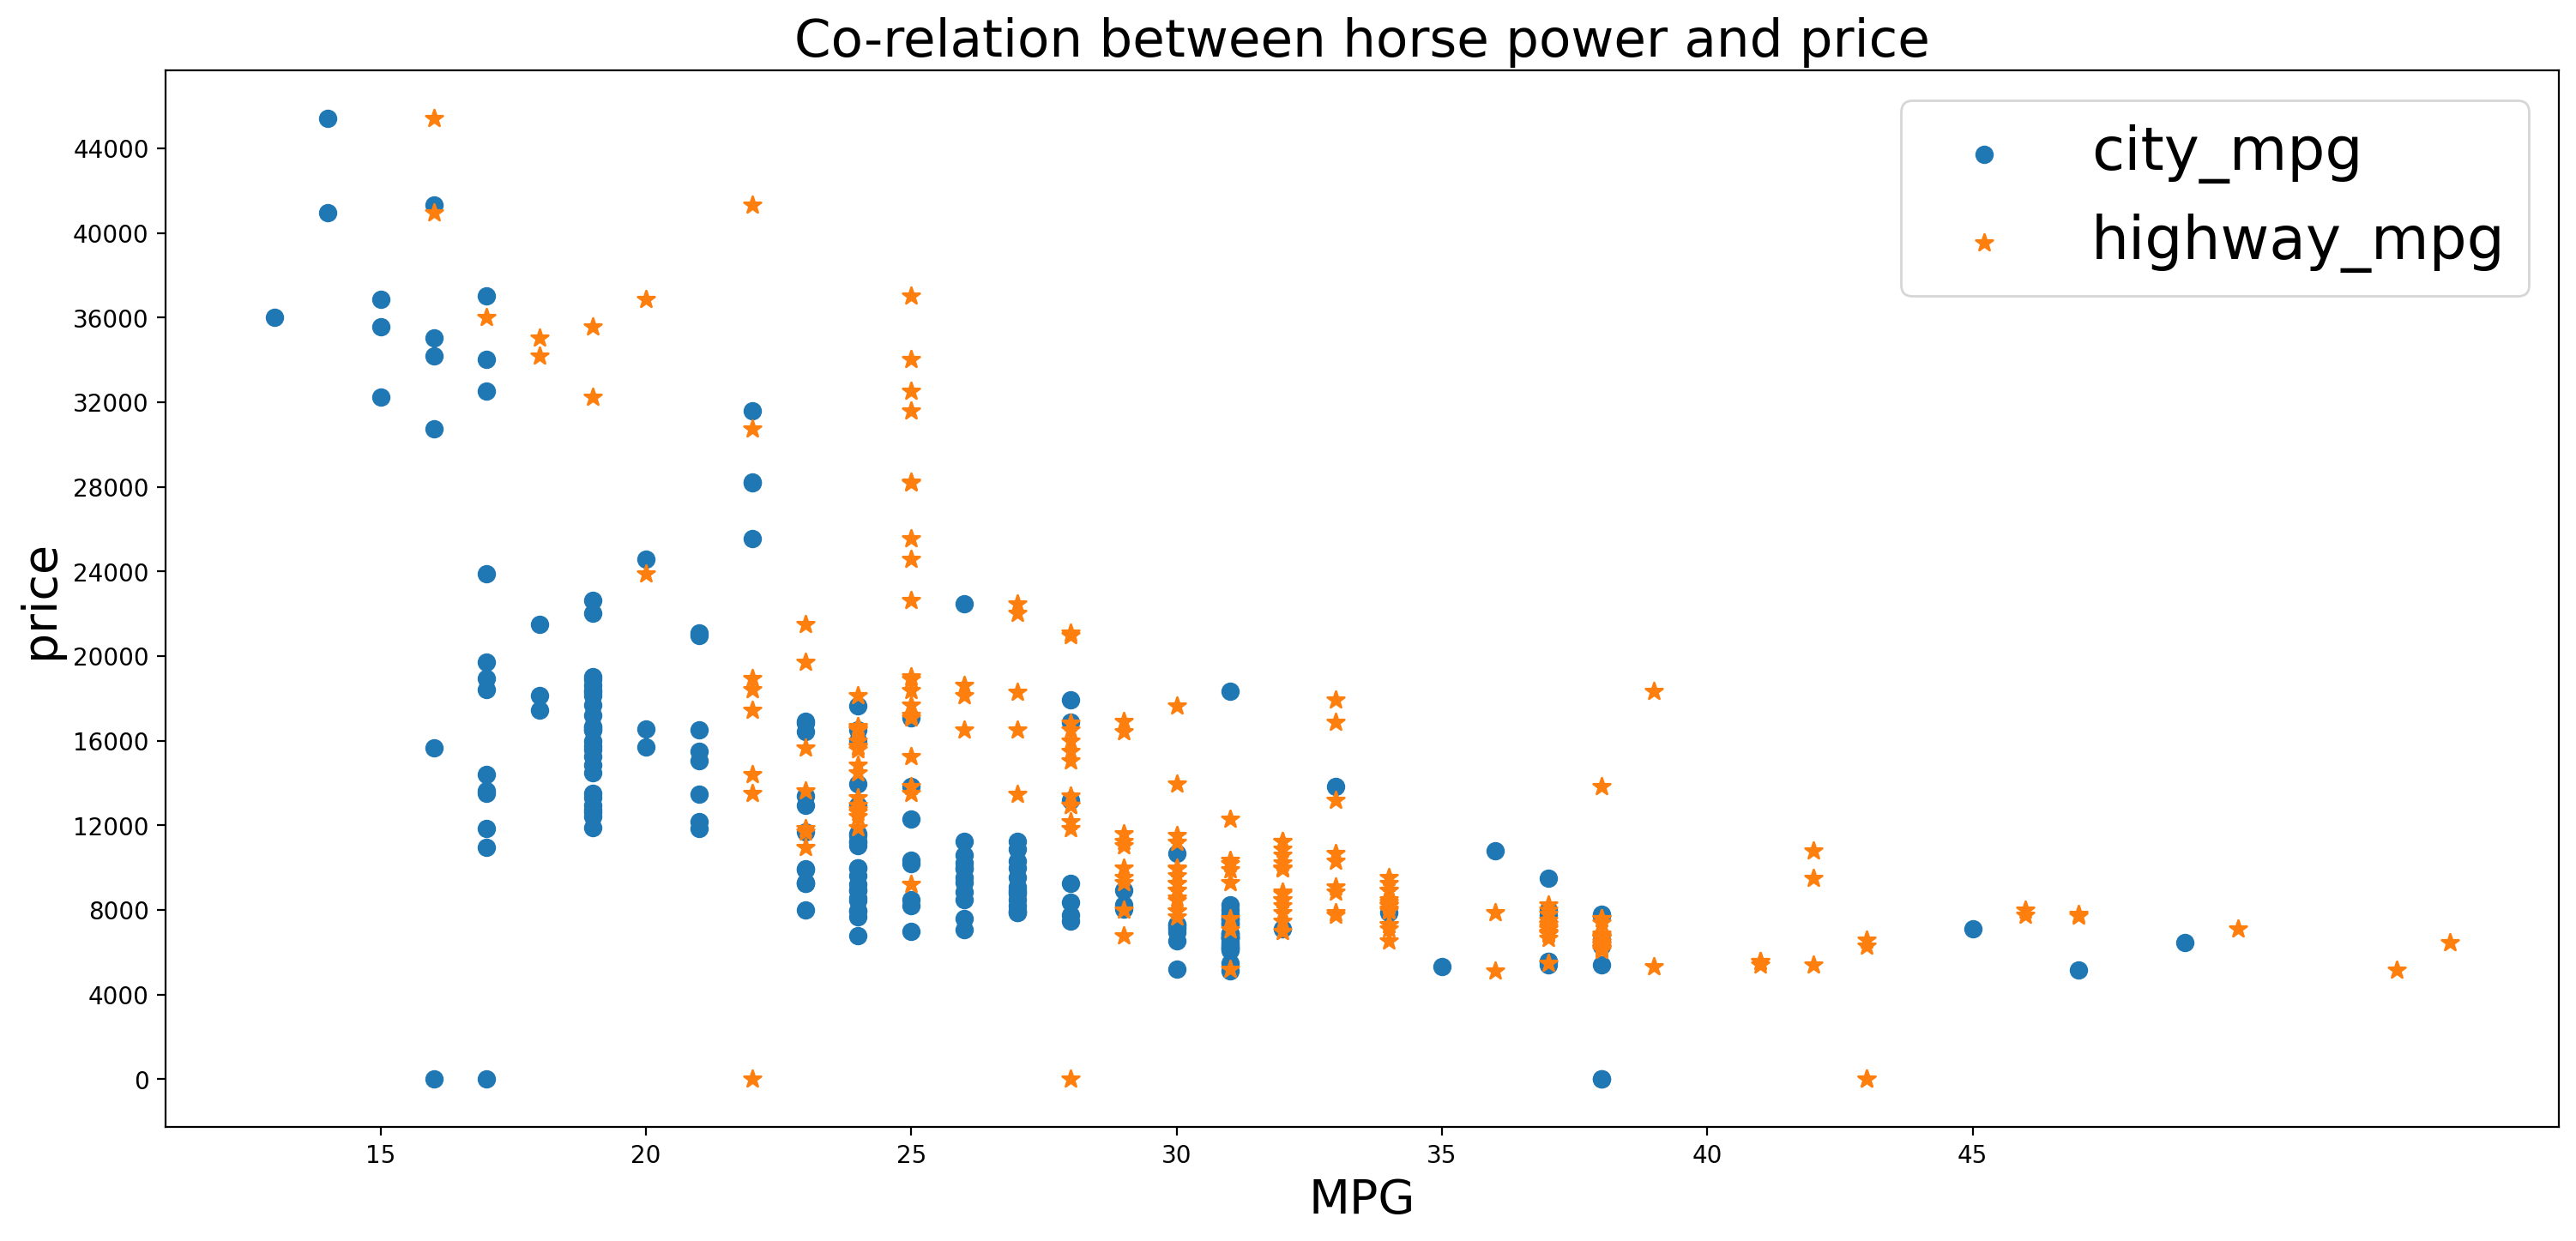

In [449]:
# shows how data is distributed 1 numeric column
plt.figure(figsize=(18,8),dpi=200)
plt.title('Co-relation between horse power and price',fontsize=22)
plt.xticks(np.arange(0,50,5))
plt.yticks(np.arange(0,55000,4000))
plt.ylabel('price',fontsize=20,color='Black')
plt.xlabel('MPG',fontsize=20,color='Black')
plt.scatter(cardf.city_mpg,cardf.price,label='city_mpg',marker='o',s=45)
plt.scatter(cardf.highway_mpg,cardf.price,label='highway_mpg',marker='*',s=55)
plt.legend(fontsize=25)
plt.show();

## Incuding Catogorical value 

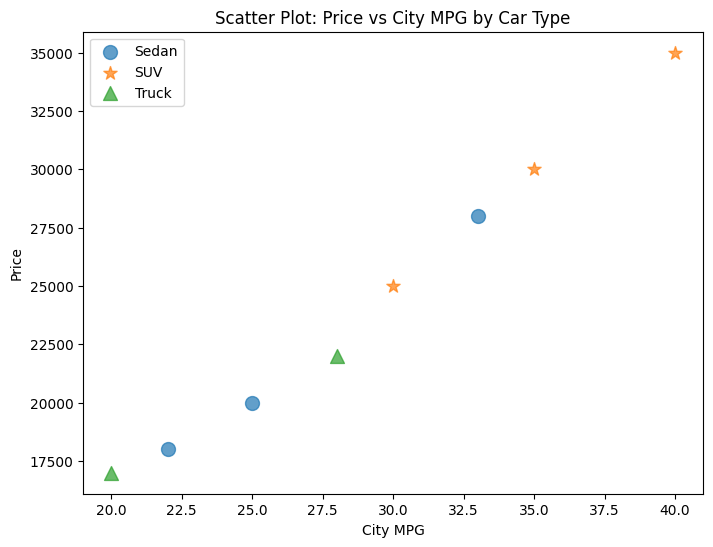

In [453]:
import matplotlib.pyplot as plt
import pandas as pd

# Example data
data = {
    'City_MPG': [25, 30, 22, 35, 28, 40, 20, 33],
    'Price': [20000, 25000, 18000, 30000, 22000, 35000, 17000, 28000],
    'Type': ['Sedan', 'SUV', 'Sedan', 'SUV', 'Truck', 'SUV', 'Truck', 'Sedan']
}

df = pd.DataFrame(data)

# Unique categories and marker styles
categories = df['Type'].unique()
markers = ['o', '*', '^']  # one marker per category

# Plot each category separately
plt.figure(figsize=(8,6))
for cat, mark in zip(categories, markers):
    subset = df[df['Type'] == cat]
    plt.scatter(subset['City_MPG'], subset['Price'], label=cat, marker=mark, s=100, alpha=0.7)

plt.xlabel('City MPG')
plt.ylabel('Price')
plt.title('Scatter Plot: Price vs City MPG by Car Type')
plt.legend()
plt.show();
